# [STARE] MATHFI -- SPLIT TESTS #3 -- LOO AGG FOLD LOOPS -- seed 1337

In [1]:
import sys, os
sys.path.append(os.path.abspath('../../'))
sys.path.append(os.path.abspath('../../../FR-UNet/'))

print( os.getcwd())
sys.path


c:\Users\s1005\OneDrive\文件\PLM_DOCS\code\githubs\Adaptive-Hierarchical-Feature-Modulation-U-Net-Model-for-Retinal-Vessel-Segmentation\notebooks\train_all


['C:\\Users\\s1005\\AppData\\Local\\Programs\\Python\\Python310\\python310.zip',
 'C:\\Users\\s1005\\AppData\\Local\\Programs\\Python\\Python310\\DLLs',
 'C:\\Users\\s1005\\AppData\\Local\\Programs\\Python\\Python310\\lib',
 'C:\\Users\\s1005\\AppData\\Local\\Programs\\Python\\Python310',
 'c:\\Users\\s1005\\OneDrive\\文件\\PLM_DOCS\\code\\githubs\\Adaptive-Hierarchical-Feature-Modulation-U-Net-Model-for-Retinal-Vessel-Segmentation\\venv310',
 '',
 'c:\\Users\\s1005\\OneDrive\\文件\\PLM_DOCS\\code\\githubs\\Adaptive-Hierarchical-Feature-Modulation-U-Net-Model-for-Retinal-Vessel-Segmentation\\venv310\\lib\\site-packages',
 'c:\\Users\\s1005\\OneDrive\\文件\\PLM_DOCS\\code\\githubs\\Adaptive-Hierarchical-Feature-Modulation-U-Net-Model-for-Retinal-Vessel-Segmentation',
 'c:\\Users\\s1005\\OneDrive\\文件\\PLM_DOCS\\code\\githubs\\FR-UNet']

In [2]:
from src.models.unet import UNet
print(UNet)

<class 'src.models.unet.UNet'>


In [3]:
from pathlib import Path
import torch
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# CHANGE THESE

In [4]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
SEED   = 1337
DATASET = "STARE" # "DRIVE" | "STARE" | "CHASEDB1"

PATCH_SIZE = 128
VAL_WINDOW  = PATCH_SIZE
VAL_OVERLAP = 0.25

VESSEL_BIAS=0.7
MIN_PERCENT_VESSEL=0.008
V_MULT=30
DENSE_BIAS=None
BATCH_SIZE=2

IMG_SIZE=512

EPOCHS = 50
warmup_epochs = 5

FOLDS = 20
FOLD_ID = 0

THRESHOLD_EVAL = 0.5


MODEL_NAME = "MATHFI"
TITLE     = f"[{DATASET}] {MODEL_NAME} NEW SPLIT ({FOLDS} folds) -- seed 1337 -- DPCN 6x64 hl=2 reduce=64 cbam=16 epochs={EPOCHS}"
SAVE_ROOT = Path(f"../../../../pth/{MODEL_NAME}_{DATASET}_NEWSPLIT")     # a clean experiment folder
SAVE_CKPT = SAVE_ROOT / "checkpoints"
SAVE_PRED = SAVE_ROOT / "predictions"   # per-image logits/prob/masks
SAVE_VIZ  = SAVE_ROOT / "visuals"       # PNG overlays per test image
SAVE_LOGS = SAVE_ROOT / "logs"
for d in [SAVE_ROOT, SAVE_CKPT, SAVE_PRED, SAVE_VIZ, SAVE_LOGS]: d.mkdir(parents=True, exist_ok=True)

DATASET_ROOT        = f"../../../../Retinal_Vessel_Segmentation_Datasets/{DATASET}/"
DATASET_LABELFOLDER = "1st_manual"




# IMPORTS

In [5]:
import os, json, math, time, random
from pathlib import Path
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim.lr_scheduler import LambdaLR
import matplotlib.pyplot as plt

# --- data utils ---
from src.data.splits import (
    split_drive_20_20,
    split_chase_subjectwise_20_8,
    split_stare_leave_one_out,
    stare_loo_fold,

    drive_random_20_20,

    chase_random_subject_split,

)

from src.data.dataloader import make_loaders
from src.data.augmentations import get_train_augs, get_val_augs

# use YOUR metrics utilities
from src.training.metrics import (
    confusion_counts,
    dice as dice_metric,
    iou as iou_metric,
    roc_auc as roc_auc_metric,
    pr_auc as pr_auc_metric,
    acc_from_counts,
    recall_from_counts,          # sensitivity
    specificity_from_counts,     # specificity
    cldice
)



# --- evaluation & visualization ---
from src.evaluation.evaluate import evaluate_and_print
from src.evaluation.visualization import visualize_samples

In [6]:
def eval_leftout_with_fov(prob_1chw: torch.Tensor,
                          gt_1chw: torch.Tensor,
                          fov_1chw: torch.Tensor,
                          thr: float = 0.5) -> dict:
    """
    Evaluate one test image (left out) using *your* metrics helpers.
    All metrics are computed *within FOV*.
    """
    # to cpu numpy
    p = prob_1chw.squeeze().detach().cpu().numpy()       # [H,W] probs in [0,1]
    g = gt_1chw.squeeze().detach().cpu().numpy()         # [H,W] {0,1}
    f = fov_1chw.squeeze().detach().cpu().numpy()        # [H,W] {0,1}

    # clamp to FOV (zero-out everything outside)
    p_f = p * (f > 0.5)
    g_f = (g > 0.5).astype(np.uint8)

    # binarize at thr (inside FOV)
    pred_f = (p_f >= thr).astype(np.uint8)

    # counts + derived metrics
    tp, fp, tn, fn = confusion_counts(pred_f, g_f)

    ACC  = float(acc_from_counts(tp, fp, tn, fn))
    SEN  = float(recall_from_counts(tp, fn))        # sensitivity / TPR
    SPE  = float(specificity_from_counts(tn, fp))
    DICE = float(dice_metric(pred_f, g_f))
    IOU  = float(iou_metric(pred_f, g_f))
    CLDICE = float(cldice(pred_f, g_f))

    # probability-based (AUCs) computed on FOV-masked prob/gt
    try:
        AUC = float(roc_auc_metric(p_f, g_f))
    except Exception:
        AUC = float("nan")
    try:
        AP = float(pr_auc_metric(p_f, g_f))
    except Exception:
        AP = float("nan")

    return dict(ACC=ACC, Dice=DICE, IoU=IOU, SEN=SEN, SPE=SPE, AUC=AUC, AP=AP,CLDICE=CLDICE,
                tp=int(tp), fp=int(fp), tn=int(tn), fn=int(fn))



# helpers and config

In [7]:
os.getcwd()

'c:\\Users\\s1005\\OneDrive\\文件\\PLM_DOCS\\code\\githubs\\Adaptive-Hierarchical-Feature-Modulation-U-Net-Model-for-Retinal-Vessel-Segmentation\\notebooks\\train_all'

In [ ]:
# --- model factory (fresh per fold) ---
from src.models.wrappers.dpcn_concat_unet import DPCNConcatUNet
BASE_KW = {"cbam_reduction": 16}

def make_model(MODEL_NAME, train_loader = None) -> nn.Module:
    if MODEL_NAME == "MATHFI":
        # --- loss ---
        from src.training.loss_functions import DiceBCEComplementLoss

        def estimate_class_weights(loader, max_batches=20):
            with torch.no_grad():
                s = 0.0; n = 0
                for i, b in enumerate(loader):
                    s += b["mask"].float().mean().item(); n += 1
                    if i+1 >= max_batches: break
            p = max(1e-6, min(1-1e-6, s / max(1, n)))
            w1 = 1.0 / p; w0 = 1.0 / (1.0 - p)
            s2 = w0 + w1; w0 = 2.0 * w0 / s2; w1 = 2.0 * w1 / s2
            return w0, w1
        
        w0, w1 = estimate_class_weights(train_loader, max_batches=20)
        loss_fn = DiceBCEComplementLoss(w0=w0, w1=w1, dice_weight=0.5, bce_weight=0.5,
                                        exact_equation=False, reduction="mean")
        
        # --- model ---
        return DPCNConcatUNet(
            in_ch=1, enh_channels=64, iters=6,
            threshold_mode="scaled_vat", half_life=2.0,
            reduce_to=64, base_kwargs=BASE_KW
        ).to(DEVICE), loss_fn

    elif MODEL_NAME == "FR-UNet":
        loss_fn = nn.BCEWithLogitsLoss()
        from models.fr_unet import FR_UNet
        return FR_UNet().to(DEVICE), loss_fn
        
@torch.no_grad()
def sliding_window_forward_logits(model, img_1chw, window, overlap, device="cuda"):
    """
    img_1chw: torch.Tensor [1,1,H,W] on *any* device.
    Returns: averaged logits [1,1,H,W] on 'device'
    """
    model.eval()
    img = img_1chw.to(device, non_blocking=True)
    _, _, H, W = img.shape
    step = max(1, int(window * (1 - overlap)))

    # we'll average *logits* to keep your loss_fn (e.g., BCEWithLogits) unchanged
    acc  = torch.zeros_like(img, device=device)
    norm = torch.zeros_like(img, device=device)

    for y0 in range(0, max(1, H - window + 1), step):
        for x0 in range(0, max(1, W - window + 1), step):
            y1 = min(y0 + window, H); x1 = min(x0 + window, W)
            y0 = y1 - window;         x0 = x1 - window
            tile = img[:, :, y0:y1, x0:x1]                     # [1,1,win,win]
            with torch.amp.autocast(device_type="cuda", enabled=(device=="cuda")):
                logit = model(tile)                            # [1,1,win,win]
            acc[:, :, y0:y1, x0:x1] += logit
            norm[:, :, y0:y1, x0:x1] += 1.0

    logits = acc / torch.clamp_min(norm, 1.0)
    return logits

@torch.no_grad()
def infer_full_logits(model: nn.Module, img_1chw: torch.Tensor, device=DEVICE, window=VAL_WINDOW, overlap=VAL_OVERLAP):
    model.eval()
    return sliding_window_forward_logits(model, img_1chw, window=window, overlap=overlap, device=device)


def add_metrics(model_name, root, label_folder, img_size, ckpt_path, threshold_eval, all_metrics, test_loader_mathfi = None):
        
        model, _ = make_model(model_name, test_loader_mathfi)
        stem = Path(ckpt_path).stem  # "STARE_fold00"
        fold_id = int(stem.split("fold")[-1])  # 0
        #print(f"checkpoint_path: {ckpt_path}\nfold_id:{fold_id}")

        _, te_pairs = stare_loo_fold(root, label_folder=label_folder, fold_id=fold_id)
        
        _, test_loader = make_loaders(
            train_pairs=te_pairs, val_pairs=te_pairs,
            image_size=img_size, batch_size=1, num_workers=1,
            seed=SEED, strict_fov=True,
            augs_train=None, augs_val=get_val_augs(img_size),
        )
        model.load_state_dict(torch.load(ckpt_path, map_location=DEVICE))
        model.eval()

        batch = next(iter(test_loader))
        x   = batch["image"].to(DEVICE)
        y   = batch["mask"].to(DEVICE)
        fov = batch.get("fov", torch.ones_like(y)).to(DEVICE)
        img_path = batch["image_path"][0]
        img_stem = Path(img_path).stem

        logits = infer_full_logits(model, x, window=VAL_WINDOW, overlap=VAL_OVERLAP, device=DEVICE)
        prob   = torch.sigmoid(logits)
        # binm   = (prob >= threshold_eval).float()

        # 6a) metrics
        # 6a) metrics — use YOUR metrics module via our wrapper
        m = eval_leftout_with_fov(prob[0,0], y[0,0], fov[0,0], thr=threshold_eval)
        m["fold_id"]  = fold_id
        m["image_id"] = img_stem
        all_metrics.append(m)

        def _fmt(v):  # pretty-print, handles NaN
            try:
                return f"{v:.4f}" if v == v else "nan"
            except Exception:
                return str(v)

        print(
            f"== [F{fold_id:02d}] {img_stem} == \n"
            + "\n".join([f"{k}={_fmt(m[k])}" for k in ["SEN","SPE", "CLDICE", "ACC","Dice","IoU","AUC"]])
        )


# --- tiny metric collector (use yours if evaluate_and_print returns a dict) ---
from sklearn.metrics import roc_auc_score, average_precision_score


# --- DATASET HYPERPARAM SCHEDULERS ---
def sched_vessel_bias(epoch):
    if epoch <= 10: return 0.70
    if epoch <= 35: return 0.60
    return 0.50

def sched_min_percent_vessel(epoch):
    if epoch <= 10: return 0.008
    if epoch <= 35: return 0.010
    return 0.008

def sched_patch_size(epoch):
    return 160 if epoch > 45 else 128

# ---- single updater ----
def update_dataset(ds, epoch):
    ds.vessel_bias_p      = sched_vessel_bias(epoch)
    ds.min_percent_vessel = sched_min_percent_vessel(epoch)
    ds.patch_size         = sched_patch_size(epoch)

    
# --- training boilerplate (pass FOV into the model so DPCN can clamp each iter) ---
def train_one_epoch(model, loader, optimizer, scaler, loss_fn, device=DEVICE):
    model.train()
    total, n = 0.0, 0
    for batch in loader:
        x   = batch["image"].to(device, non_blocking=True)
        y   = batch["mask"].to(device,  non_blocking=True)
        fov = batch.get("fov", torch.ones_like(y)).to(device, non_blocking=True)

        # restrict labels to FOV (keeps loss fair)
        y = y * (fov > 0.5).float()

        optimizer.zero_grad(set_to_none=True)
        with torch.amp.autocast(device_type="cuda", enabled=(device=="cuda")):
            if model.uses_fov: logits = model(x, fov=fov)          # << pass FOV so DPCN uses it
            else: logits = model(x)
            loss   = loss_fn(logits, y)

        scaler.scale(loss).backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(optimizer); scaler.update()

        total += loss.item() * x.size(0); n += x.size(0)
    return total / max(1, n)

@torch.no_grad()
def validate_loss_only(model, loader, loss_fn,  window, overlap, device=DEVICE,):
    model.eval()
    total, n = 0.0, 0
    for batch in loader:
        x   = batch["image"].to(device, non_blocking=True)
        y   = batch["mask"].to(device,  non_blocking=True)
        fov = batch.get("fov", torch.ones_like(y)).to(device, non_blocking=True)

        for i in range(x.size(0)):
            logits_i = infer_full_logits(model, x[i:i+1], device=device, window=window, overlap=overlap)
            yi = y[i:i+1] * (fov[i:i+1] > 0.5).float()
            with torch.amp.autocast(device_type="cuda", enabled=(device=="cuda")):
                loss_i = loss_fn(logits_i, yi)
            total += loss_i.item(); n += 1
    return total / max(1, n)

def atomic_torch_save(state, path: Path):
    path = Path(path); tmp = path.with_suffix(path.suffix + ".partial")
    try: tmp.unlink()
    except FileNotFoundError: pass
    with open(tmp, "wb") as f:
        torch.save(state, f); f.flush(); os.fsync(f.fileno())
    os.replace(tmp, path)



# MAIN RUN

In [ ]:
# --- main LOO run ---
def run_stare_loo_experiment(
    root=DATASET_ROOT, label_folder=DATASET_LABELFOLDER, epochs=EPOCHS, warmup=warmup_epochs, V_MULT=V_MULT,
    batch_size=BATCH_SIZE, img_size=IMG_SIZE, patch_train=True, patch_size=PATCH_SIZE, vessel_bias_p=VESSEL_BIAS,
    threshold_eval=THRESHOLD_EVAL, folds=FOLDS, fold_id=0, chckpnt_paths=None
):  
    rng = np.random.RandomState(SEED)
    all_metrics = []
    per_image_preds = {}   # img_stem -> dict(prob_path, bin_path, fold_id)
    
    while fold_id < folds:
        
        # add checkpoint paths to metric list
        if chckpnt_paths:
            for ckpt in chckpnt_paths:
                add_metrics(MODEL_NAME, 
                            DATASET_ROOT, 
                            DATASET_LABELFOLDER,
                            img_size, ckpt, 
                            threshold_eval, all_metrics) 
            chckpnt_paths.clear()

        print(f"\n========== {MODEL_NAME} {DATASET} NEW SPLIT, Fold {fold_id+1}/{folds} ==========")

        # 1) split
        tr_pairs, te_pairs = stare_loo_fold(root, label_folder=label_folder, fold_id=fold_id)
        # 2) carve val deterministically from the 19 train images (e.g., last 3)
        val_pairs = tr_pairs[-3:]
        tr_pairs_ = tr_pairs[:-3]

        # 3) loaders
        train_loader, val_loader = make_loaders(
            train_pairs=tr_pairs_, val_pairs=val_pairs,
            image_size=img_size, batch_size=batch_size, num_workers=1,
            seed=SEED + fold_id, strict_fov=True,
            augs_train=get_train_augs(img_size),
            augs_val=get_val_augs(img_size),
            patch_train=patch_train, patch_size=patch_size,
            vessel_bias_p=vessel_bias_p, virtual_mult=V_MULT,
        )
        _, test_loader = make_loaders(
            train_pairs=te_pairs, val_pairs=te_pairs,
            image_size=img_size, batch_size=1, num_workers=1,
            seed=SEED, strict_fov=True,
            augs_train=None, augs_val=get_val_augs(img_size),
        )

        # 4) model & optimizer
        model, loss_fn = make_model(MODEL_NAME, train_loader)
        model.uses_fov = MODEL_NAME == "MATHFI"     # whether to pass fov in forward or not

        


        optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)
        scaler    = torch.amp.GradScaler("cuda", enabled=(DEVICE=="cuda"))
        def lr_lambda(e):
            if e < warmup: return (e+1)/max(1, warmup)
            progress = (e - warmup) / max(1, epochs - warmup)
            return 0.5 * (1 + math.cos(math.pi * progress))
        scheduler = LambdaLR(optimizer, lr_lambda)

        # 5) train with best-val checkpointing
        best_val = float("inf")
        ckpt_path = SAVE_CKPT / f"{DATASET}_fold{fold_id:02d}.pth"

        train_losses, val_losses = [], []

        for ep in range(1, epochs+1):
            update_dataset(train_loader.dataset, ep)
            t0=time.time()
            tr_loss  = train_one_epoch(model, train_loader, optimizer, scaler, loss_fn)
            val_loss = validate_loss_only(model, val_loader, loss_fn, PATCH_SIZE, VAL_OVERLAP)
            scheduler.step()
            print(f"[F{fold_id:02d} E{ep:03d}] train={tr_loss:.4f} val={val_loss:.4f} "
                  f"lr={optimizer.param_groups[0]['lr']:.2e} time={(time.time()-t0):.1f}s")
            
            
            train_losses.append(float(tr_loss))
            val_losses.append(float(val_loss))

            if val_loss < best_val:
                best_val = val_loss
                atomic_torch_save(model.state_dict(), ckpt_path)
                print(f"\tCHECKPOINT SAVED: {ckpt_path}")
        
        #val loss vs train loss
        plt.figure(figsize=(6,3.5))
        plt.plot(range(1, len(train_losses)+1), train_losses, label="train")
        plt.plot(range(1, len(val_losses)+1),   val_losses,   label="val")
        plt.xlabel("epoch"); plt.ylabel("loss"); plt.grid(True); plt.legend()
        plt.title("Train vs Val Loss:" + TITLE)
        plt.tight_layout()
        plt.show()

        # 6) eval on left-out image using best checkpoint

        model.load_state_dict(torch.load(ckpt_path, map_location=DEVICE))
        model.eval()

        batch = next(iter(test_loader))
        x   = batch["image"].to(DEVICE)
        y   = batch["mask"].to(DEVICE)
        fov = batch.get("fov", torch.ones_like(y)).to(DEVICE)
        img_path = batch["image_path"][0]
        img_stem = Path(img_path).stem

        logits = infer_full_logits(model, x, window=VAL_WINDOW, overlap=VAL_OVERLAP, device=DEVICE)
        prob   = torch.sigmoid(logits)
        binm   = (prob >= threshold_eval).float()

        # 6a) metrics
        # 6a) metrics — use YOUR metrics module via our wrapper
        m = eval_leftout_with_fov(prob[0,0], y[0,0], fov[0,0], thr=threshold_eval)
        m["fold_id"]  = fold_id
        m["image_id"] = img_stem
        all_metrics.append(m)

        def _fmt(v):  # pretty-print, handles NaN
            try:
                return f"{v:.4f}" if v == v else "nan"
            except Exception:
                return str(v)

        print(
            f"== [F{fold_id:02d}] {img_stem} == \n"
            + "\n".join([f"{k}={_fmt(m[k])}" for k in ["SEN","SPE", "CLDICE", "ACC","Dice","IoU","AUC"]])
        )


        # 6b) save predictions
        SAVE_FILE = SAVE_PRED / f"{img_stem}__fold{fold_id:02d}.pt"
        torch.save({"logits": logits.cpu(), "prob": prob.cpu(), "bin": binm.cpu(),
                    "image_path": img_path, "fold": fold_id},
                  SAVE_FILE)
        per_image_preds[img_stem] = dict(
            prob_path=str((SAVE_PRED / f"{img_stem}__fold{fold_id:02d}.pt").as_posix()),
            fold_id=fold_id
        )

        print(f"== Predictions SAVED TO FILE: {SAVE_FILE} ==")

        # 6c) quick visualization panel for this test image
        fig, axs = plt.subplots(1,4, figsize=(12,3))
        axs[0].imshow(x[0,0].cpu(), cmap="gray"); axs[0].set_title("Image"); axs[0].axis("off")
        axs[1].imshow(y[0,0].cpu(), cmap="gray"); axs[1].set_title("GT");    axs[1].axis("off")
        axs[2].imshow(prob[0,0].cpu(), cmap="gray"); axs[2].set_title("Prob"); axs[2].axis("off")
        axs[3].imshow(binm[0,0].cpu(), cmap="gray"); axs[3].set_title(f"Pred@{threshold_eval}"); axs[3].axis("off")
        fig.suptitle(f"{DATASET} NEW SPLITS Fold {fold_id} — {img_stem}")
        plt.tight_layout(); plt.show(); fig.savefig(SAVE_VIZ / f"{img_stem}__fold{fold_id:02d}.png", dpi=150)
        plt.close(fig)

        fold_id = fold_id + 1

        # END OF FOLD LOOP
    


    # 7) aggregate & save CSV
    import csv
    keys = ["fold_id","image_id","SEN","SPE", "CLDICE", "ACC","Dice","IoU","AUC","AP"]
    csv_path = SAVE_LOGS / f"{DATASET}_newSplit_perfold.csv"
    with open(csv_path, "w", newline="") as f:
        w = csv.DictWriter(f, fieldnames=keys); w.writeheader()
        for row in all_metrics: w.writerow({k: row.get(k, "") for k in keys})

    # mean±std
    def _ms(name):
        arr = np.array([r[name] for r in all_metrics if not np.isnan(r[name])], dtype=float)
        return float(arr.mean()), float(arr.std(ddof=1)) if arr.size > 1 else 0.0
    summary = {k: _ms(k) for k in ["SEN","SPE","CLDICE","ACC","Dice","IoU","AUC","AP"]}
    print(f"\n=== {MODEL_NAME} {DATASET} NEW SPLITS ({FOLDS} folds) — mean ± std ===")
    for k,(mu,sig) in summary.items():
        print(f"{k}: {mu:.4f} ± {sig:.4f}")

    with open(SAVE_LOGS / f"{DATASET}_newSplit_summary.json","w") as f:
        json.dump({k: {"mean": mu, "std": sig} for k,(mu,sig) in summary.items()}, f, indent=2)

    # 8) (optional) gallery index of unbiased predictions
    with open(SAVE_LOGS / f"{DATASET}_newSplit_per_image_preds.json","w") as f:
        json.dump(per_image_preds, f, indent=2)

    return all_metrics, summary


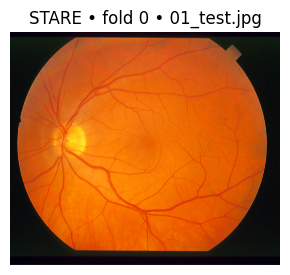

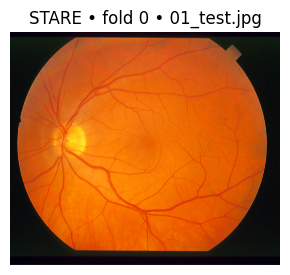

== [F00] 01_test == 
SEN=0.7810
SPE=0.9815
CLDICE=0.7332
ACC=0.9692
Dice=0.7568
IoU=0.6088
AUC=0.9868


In [ ]:
# Check indiv chkpoint paths scores

check_checkpoints = [
 "..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\checkpoints\STARE_fold00.pth",
]
stem = Path(check_checkpoints[0]).stem  # "STARE_fold00"
fold_id = int(stem.split("fold")[-1])  # 0

if MODEL_NAME == "MATHFI":
    _, te_pairs_mathfi = stare_loo_fold(DATASET_ROOT, label_folder=DATASET_LABELFOLDER, fold_id=FOLD_ID)

    _, test_loader_mathfi = make_loaders(
        train_pairs=te_pairs_mathfi, val_pairs=te_pairs_mathfi,
        image_size=IMG_SIZE, batch_size=1, num_workers=1,
        seed=SEED, strict_fov=True,
        augs_train=None, augs_val=get_val_augs(IMG_SIZE),
    )
else: test_loader_mathfi=None

for checkpoint in check_checkpoints:
    add_metrics(MODEL_NAME,
                DATASET_ROOT, 
                DATASET_LABELFOLDER,
                IMG_SIZE, 
                checkpoint,
                THRESHOLD_EVAL, []
                , test_loader_mathfi=test_loader_mathfi)
    


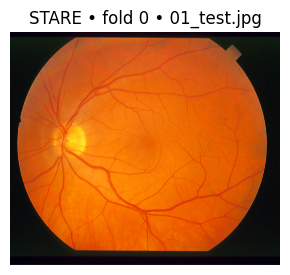

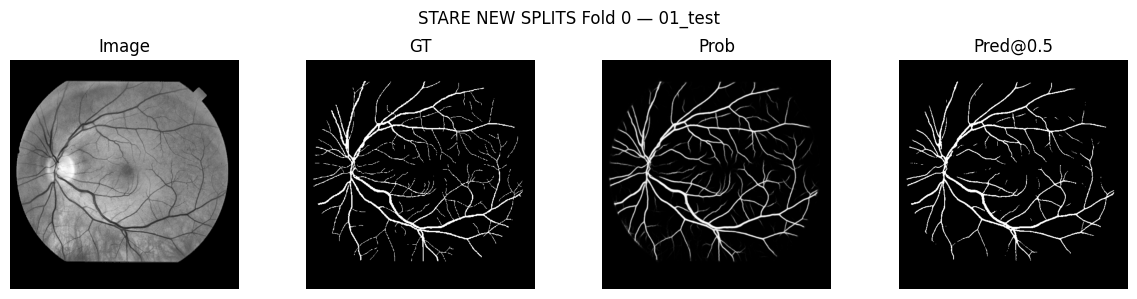

In [30]:

path = r"..\..\..\..\pth\FR-UNet_STARE_NEWSPLIT\predictions\01_test__fold00.pt"
data = torch.load(path, map_location="cpu")

stem = Path(path).stem  # "STARE_fold00"
fold_id = int(stem.split("fold")[-1])  # 0

_, te_pairs = stare_loo_fold(DATASET_ROOT, label_folder=DATASET_LABELFOLDER, fold_id=fold_id)

_, test_loader = make_loaders(
    train_pairs=te_pairs, val_pairs=te_pairs,
    image_size=IMG_SIZE, batch_size=1, num_workers=1,
    seed=SEED, strict_fov=True,
    augs_train=None, augs_val=get_val_augs(IMG_SIZE),
)

batch = next(iter(test_loader))
x   = batch["image"].to(DEVICE)
y   = batch["mask"].to(DEVICE)
logits = data["logits"]   # raw model outputs before sigmoid
prob   = data["prob"]     # probability map (0–1)
binm   = data["bin"]      # binary mask (0 or 1)
img_path = data["image_path"]
fold_id = data["fold"]
img_stem = Path(batch["image_path"][0]).stem

fig, axs = plt.subplots(1,4, figsize=(12,3))
axs[0].imshow(x[0,0].cpu(), cmap="gray"); axs[0].set_title("Image"); axs[0].axis("off")
axs[1].imshow(y[0,0].cpu(), cmap="gray"); axs[1].set_title("GT");    axs[1].axis("off")
axs[2].imshow(prob[0,0].cpu(), cmap="gray"); axs[2].set_title("Prob"); axs[2].axis("off")
axs[3].imshow(binm[0,0].cpu(), cmap="gray"); axs[3].set_title(f"Pred@0.5"); axs[3].axis("off")
fig.suptitle(f"{DATASET} NEW SPLITS Fold {fold_id} — {img_stem}")
plt.tight_layout(); plt.show()



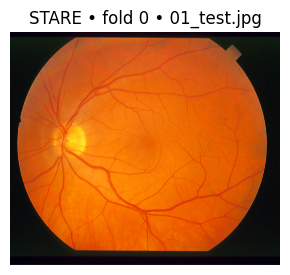

In [15]:

tr_pairs, te_pairs = stare_loo_fold(DATASET_ROOT, label_folder=DATASET_LABELFOLDER, fold_id=fold_id)
# 2) carve val deterministically from the 19 train images (e.g., last 3)
val_pairs = tr_pairs[-3:]
tr_pairs_ = tr_pairs[:-3]

# 3) loaders
train_loader, val_loader = make_loaders(
train_pairs=tr_pairs_, val_pairs=val_pairs,
image_size=IMG_SIZE, batch_size=BATCH_SIZE, num_workers=1,
seed=SEED + fold_id, strict_fov=True,
augs_train=get_train_augs(IMG_SIZE),
augs_val=get_val_augs(IMG_SIZE),
patch_train=True, patch_size=PATCH_SIZE,
vessel_bias_p=VESSEL_BIAS, virtual_mult=V_MULT,
)
_, test_loader = make_loaders(
train_pairs=te_pairs, val_pairs=te_pairs,
image_size=IMG_SIZE, batch_size=1, num_workers=1,
seed=SEED, strict_fov=True,
augs_train=None, augs_val=get_val_augs(IMG_SIZE),
)
model, loss_fn = make_model(MODEL_NAME, train_loader)
model.uses_fov = MODEL_NAME == "MATHFI"

In [16]:
model.uses_fov

True


========== MATHFI STARE NEW SPLIT, Fold 1/20 ==========


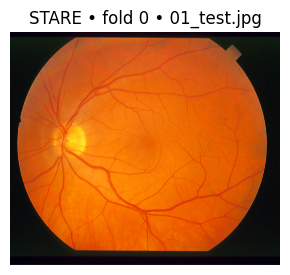

[F00 E001] train=1.0722 val=1.1194 lr=1.20e-04 time=36.1s
	CHECKPOINT SAVED: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\checkpoints\STARE_fold00.pth
[F00 E002] train=0.8106 val=0.9671 lr=1.80e-04 time=38.3s
	CHECKPOINT SAVED: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\checkpoints\STARE_fold00.pth
[F00 E003] train=0.6331 val=0.7419 lr=2.40e-04 time=47.3s
	CHECKPOINT SAVED: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\checkpoints\STARE_fold00.pth
[F00 E004] train=0.5413 val=0.7353 lr=3.00e-04 time=55.1s
	CHECKPOINT SAVED: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\checkpoints\STARE_fold00.pth
[F00 E005] train=0.4836 val=0.6221 lr=3.00e-04 time=47.3s
	CHECKPOINT SAVED: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\checkpoints\STARE_fold00.pth
[F00 E006] train=0.4553 val=0.5872 lr=3.00e-04 time=42.9s
	CHECKPOINT SAVED: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\checkpoints\STARE_fold00.pth
[F00 E007] train=0.4321 val=0.5988 lr=2.99e-04 time=42.4s
[F00 E008] train=0.4285 val=0.6036 lr=2.97e-04 time=60.0s
[F00 E009] train=0.4

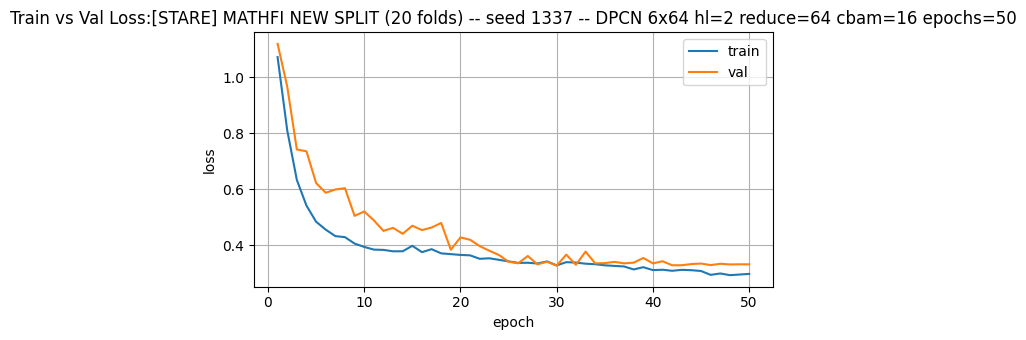

== [F00] 01_test == 
SEN=0.7810
SPE=0.9815
CLDICE=0.7332
ACC=0.9692
Dice=0.7568
IoU=0.6088
AUC=0.9868
== Predictions SAVED TO FILE: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\predictions\01_test__fold00.pt ==


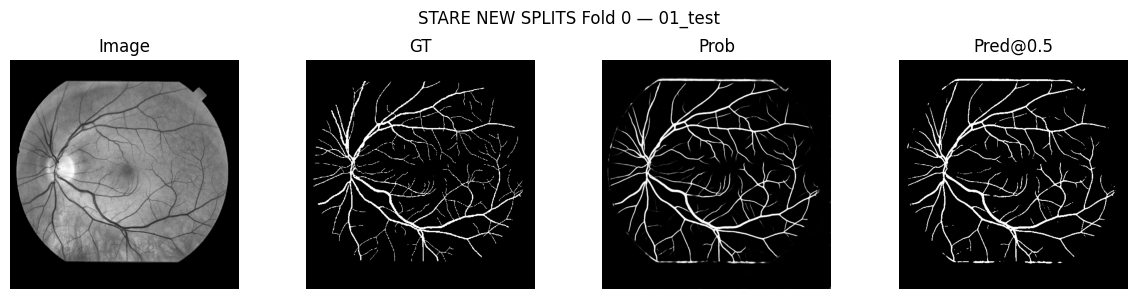


========== MATHFI STARE NEW SPLIT, Fold 2/20 ==========


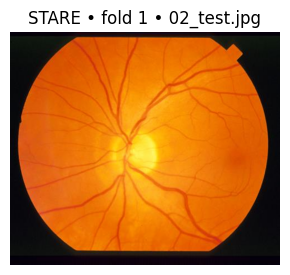

[F01 E001] train=1.0168 val=1.2473 lr=1.20e-04 time=39.5s
	CHECKPOINT SAVED: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\checkpoints\STARE_fold01.pth
[F01 E002] train=0.7756 val=0.9241 lr=1.80e-04 time=37.2s
	CHECKPOINT SAVED: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\checkpoints\STARE_fold01.pth
[F01 E003] train=0.6130 val=0.7469 lr=2.40e-04 time=37.9s
	CHECKPOINT SAVED: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\checkpoints\STARE_fold01.pth
[F01 E004] train=0.5091 val=0.6432 lr=3.00e-04 time=39.6s
	CHECKPOINT SAVED: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\checkpoints\STARE_fold01.pth
[F01 E005] train=0.4704 val=0.5888 lr=3.00e-04 time=36.9s
	CHECKPOINT SAVED: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\checkpoints\STARE_fold01.pth
[F01 E006] train=0.4428 val=0.6136 lr=3.00e-04 time=37.5s
[F01 E007] train=0.4220 val=0.5607 lr=2.99e-04 time=37.1s
	CHECKPOINT SAVED: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\checkpoints\STARE_fold01.pth
[F01 E008] train=0.4273 val=0.5619 lr=2.97e-04 time=35.5s
[F01 E009] train=0.3

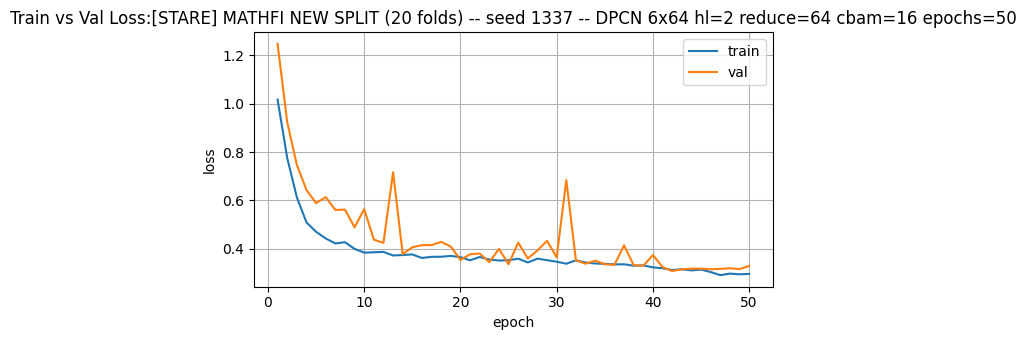

== [F01] 02_test == 
SEN=0.8743
SPE=0.9766
CLDICE=0.8413
ACC=0.9697
Dice=0.7945
IoU=0.6591
AUC=0.9897
== Predictions SAVED TO FILE: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\predictions\02_test__fold01.pt ==


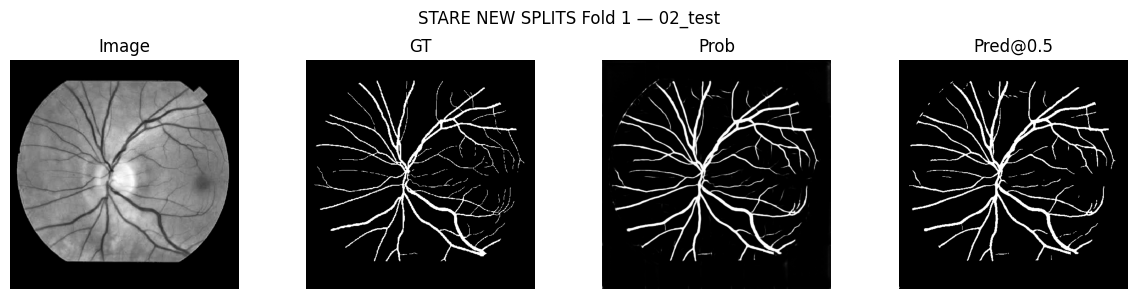


========== MATHFI STARE NEW SPLIT, Fold 3/20 ==========


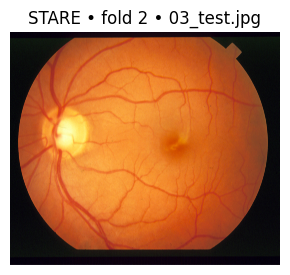

[F02 E001] train=1.1487 val=1.5371 lr=1.20e-04 time=35.1s
	CHECKPOINT SAVED: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\checkpoints\STARE_fold02.pth
[F02 E002] train=0.8861 val=0.9738 lr=1.80e-04 time=36.5s
	CHECKPOINT SAVED: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\checkpoints\STARE_fold02.pth
[F02 E003] train=0.6756 val=0.7911 lr=2.40e-04 time=36.8s
	CHECKPOINT SAVED: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\checkpoints\STARE_fold02.pth
[F02 E004] train=0.5410 val=0.9095 lr=3.00e-04 time=35.0s
[F02 E005] train=0.4843 val=0.6129 lr=3.00e-04 time=34.6s
	CHECKPOINT SAVED: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\checkpoints\STARE_fold02.pth
[F02 E006] train=0.4418 val=0.5603 lr=3.00e-04 time=36.9s
	CHECKPOINT SAVED: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\checkpoints\STARE_fold02.pth
[F02 E007] train=0.4294 val=0.5573 lr=2.99e-04 time=36.1s
	CHECKPOINT SAVED: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\checkpoints\STARE_fold02.pth
[F02 E008] train=0.4276 val=0.4592 lr=2.97e-04 time=36.7s
	CHECKPOINT SAVED: .

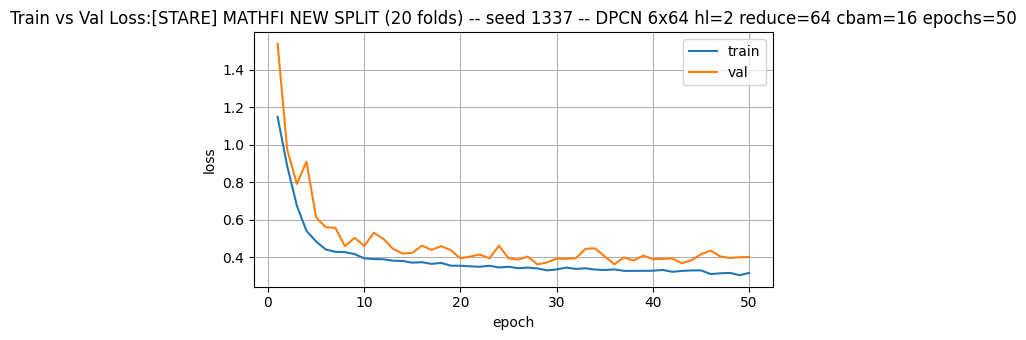

== [F02] 03_test == 
SEN=0.8199
SPE=0.9821
CLDICE=0.7859
ACC=0.9696
Dice=0.8061
IoU=0.6752
AUC=0.9896
== Predictions SAVED TO FILE: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\predictions\03_test__fold02.pt ==


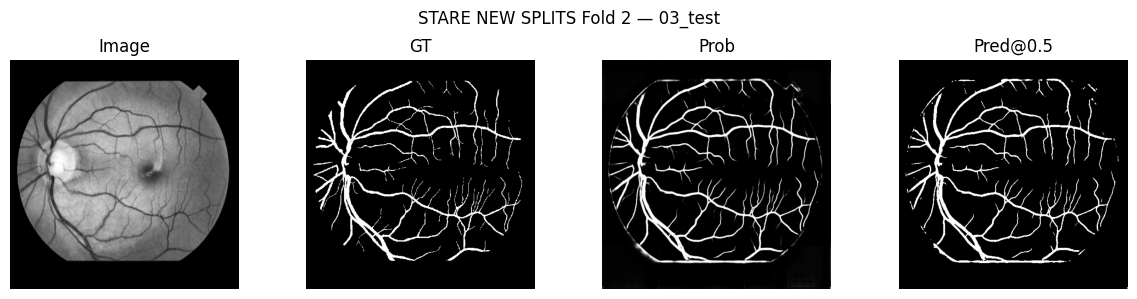


========== MATHFI STARE NEW SPLIT, Fold 4/20 ==========


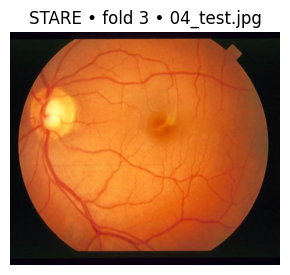

[F03 E001] train=1.0851 val=1.0788 lr=1.20e-04 time=37.9s
	CHECKPOINT SAVED: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\checkpoints\STARE_fold03.pth
[F03 E002] train=0.8245 val=0.9551 lr=1.80e-04 time=38.9s
	CHECKPOINT SAVED: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\checkpoints\STARE_fold03.pth
[F03 E003] train=0.6494 val=0.7632 lr=2.40e-04 time=37.6s
	CHECKPOINT SAVED: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\checkpoints\STARE_fold03.pth
[F03 E004] train=0.5313 val=0.6904 lr=3.00e-04 time=36.9s
	CHECKPOINT SAVED: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\checkpoints\STARE_fold03.pth
[F03 E005] train=0.4799 val=0.6906 lr=3.00e-04 time=36.4s
[F03 E006] train=0.4557 val=0.5989 lr=3.00e-04 time=40.5s
	CHECKPOINT SAVED: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\checkpoints\STARE_fold03.pth
[F03 E007] train=0.4281 val=0.4858 lr=2.99e-04 time=39.2s
	CHECKPOINT SAVED: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\checkpoints\STARE_fold03.pth
[F03 E008] train=0.4284 val=0.4964 lr=2.97e-04 time=37.4s
[F03 E009] train=0.3

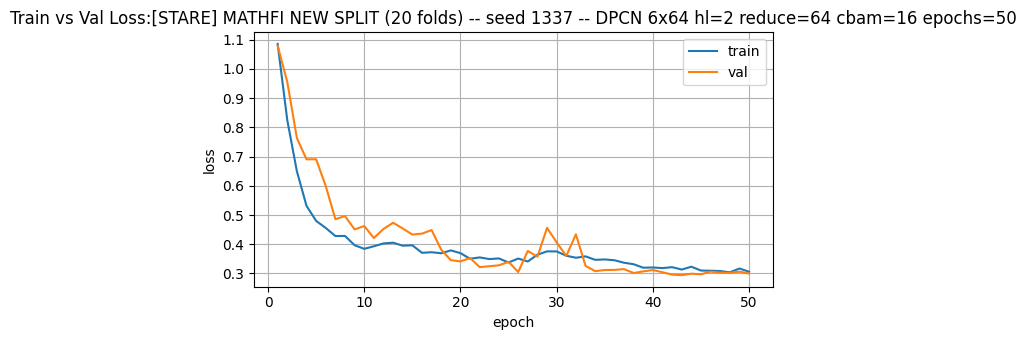

== [F03] 04_test == 
SEN=0.7661
SPE=0.9891
CLDICE=0.8340
ACC=0.9715
Dice=0.8093
IoU=0.6797
AUC=0.9876
== Predictions SAVED TO FILE: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\predictions\04_test__fold03.pt ==


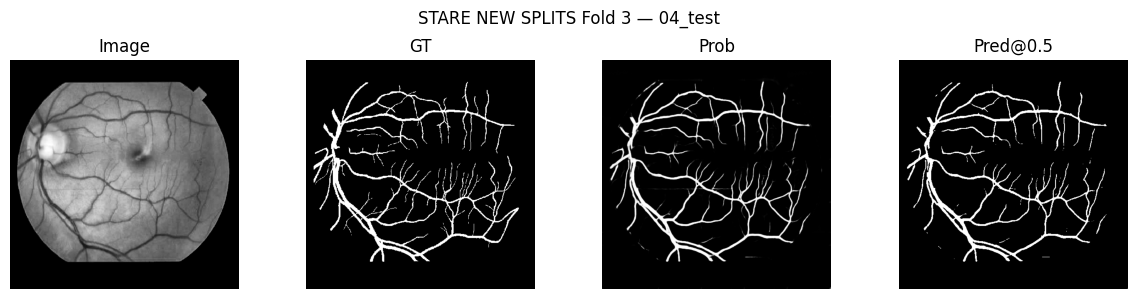


========== MATHFI STARE NEW SPLIT, Fold 5/20 ==========


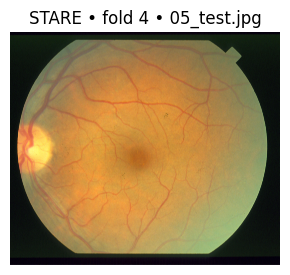

[F04 E001] train=1.1072 val=1.3200 lr=1.20e-04 time=33.5s
	CHECKPOINT SAVED: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\checkpoints\STARE_fold04.pth
[F04 E002] train=0.8447 val=0.9251 lr=1.80e-04 time=34.9s
	CHECKPOINT SAVED: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\checkpoints\STARE_fold04.pth
[F04 E003] train=0.6733 val=0.7271 lr=2.40e-04 time=35.5s
	CHECKPOINT SAVED: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\checkpoints\STARE_fold04.pth
[F04 E004] train=0.5451 val=0.6470 lr=3.00e-04 time=34.9s
	CHECKPOINT SAVED: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\checkpoints\STARE_fold04.pth
[F04 E005] train=0.4857 val=0.7356 lr=3.00e-04 time=35.8s
[F04 E006] train=0.4470 val=0.5422 lr=3.00e-04 time=34.2s
	CHECKPOINT SAVED: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\checkpoints\STARE_fold04.pth
[F04 E007] train=0.4397 val=0.5627 lr=2.99e-04 time=34.5s
[F04 E008] train=0.4406 val=0.5985 lr=2.97e-04 time=33.3s
[F04 E009] train=0.3976 val=0.4447 lr=2.94e-04 time=34.5s
	CHECKPOINT SAVED: ..\..\..\..\pth\MATHFI_STARE_

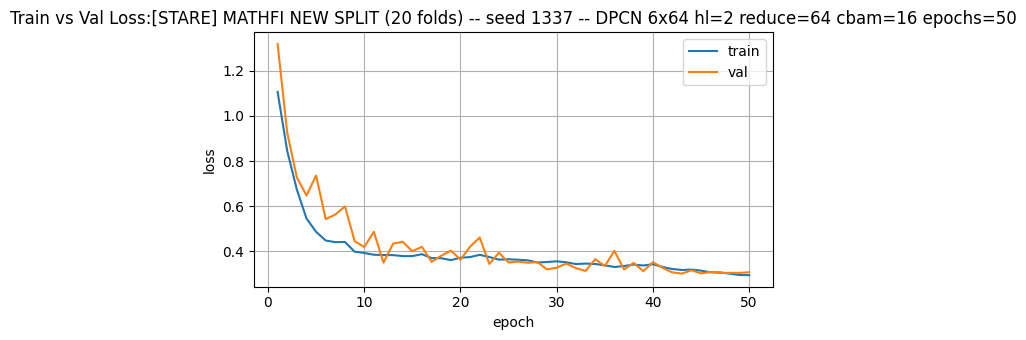

== [F04] 05_test == 
SEN=0.7538
SPE=0.9881
CLDICE=0.8226
ACC=0.9706
Dice=0.7933
IoU=0.6575
AUC=0.9866
== Predictions SAVED TO FILE: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\predictions\05_test__fold04.pt ==


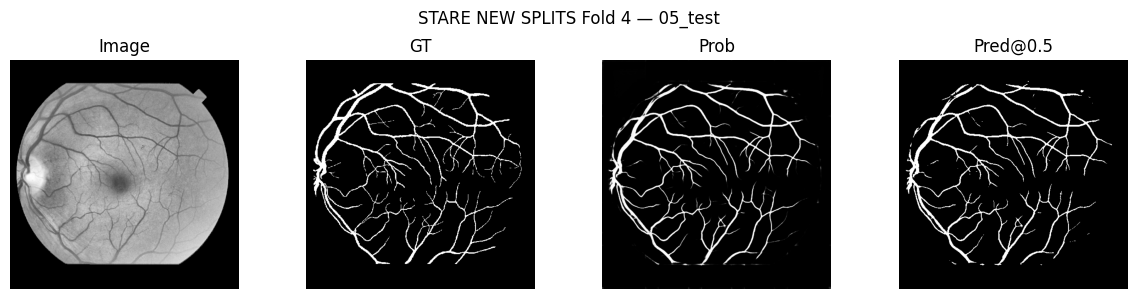


========== MATHFI STARE NEW SPLIT, Fold 6/20 ==========


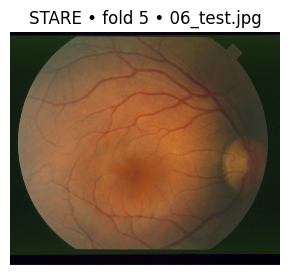

[F05 E001] train=1.0719 val=1.0905 lr=1.20e-04 time=34.6s
	CHECKPOINT SAVED: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\checkpoints\STARE_fold05.pth
[F05 E002] train=0.8088 val=0.8321 lr=1.80e-04 time=36.1s
	CHECKPOINT SAVED: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\checkpoints\STARE_fold05.pth
[F05 E003] train=0.6346 val=0.8051 lr=2.40e-04 time=34.2s
	CHECKPOINT SAVED: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\checkpoints\STARE_fold05.pth
[F05 E004] train=0.5306 val=0.6953 lr=3.00e-04 time=33.3s
	CHECKPOINT SAVED: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\checkpoints\STARE_fold05.pth
[F05 E005] train=0.4767 val=0.7823 lr=3.00e-04 time=37.2s
[F05 E006] train=0.4587 val=0.5168 lr=3.00e-04 time=34.8s
	CHECKPOINT SAVED: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\checkpoints\STARE_fold05.pth
[F05 E007] train=0.4279 val=0.5368 lr=2.99e-04 time=36.3s
[F05 E008] train=0.4314 val=0.5193 lr=2.97e-04 time=33.6s
[F05 E009] train=0.4069 val=0.4791 lr=2.94e-04 time=35.6s
	CHECKPOINT SAVED: ..\..\..\..\pth\MATHFI_STARE_

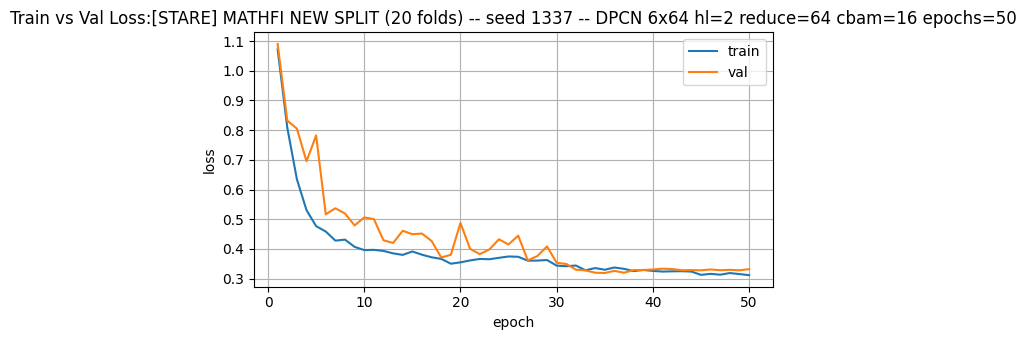

== [F05] 06_test == 
SEN=0.6386
SPE=0.9925
CLDICE=0.8154
ACC=0.9613
Dice=0.7442
IoU=0.5926
AUC=0.9729
== Predictions SAVED TO FILE: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\predictions\06_test__fold05.pt ==


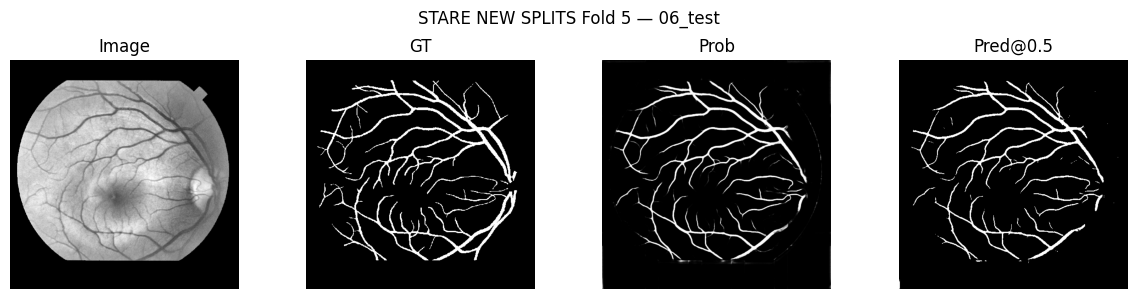


========== MATHFI STARE NEW SPLIT, Fold 7/20 ==========


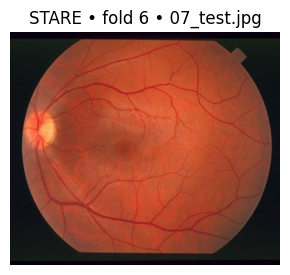

[F06 E001] train=1.2375 val=1.2148 lr=1.20e-04 time=36.6s
	CHECKPOINT SAVED: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\checkpoints\STARE_fold06.pth
[F06 E002] train=0.9517 val=0.9994 lr=1.80e-04 time=35.7s
	CHECKPOINT SAVED: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\checkpoints\STARE_fold06.pth
[F06 E003] train=0.7486 val=0.8288 lr=2.40e-04 time=36.7s
	CHECKPOINT SAVED: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\checkpoints\STARE_fold06.pth
[F06 E004] train=0.5844 val=0.6792 lr=3.00e-04 time=35.9s
	CHECKPOINT SAVED: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\checkpoints\STARE_fold06.pth
[F06 E005] train=0.4946 val=0.8463 lr=3.00e-04 time=35.6s
[F06 E006] train=0.4564 val=0.5909 lr=3.00e-04 time=37.8s
	CHECKPOINT SAVED: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\checkpoints\STARE_fold06.pth
[F06 E007] train=0.4294 val=0.5772 lr=2.99e-04 time=36.6s
	CHECKPOINT SAVED: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\checkpoints\STARE_fold06.pth
[F06 E008] train=0.4108 val=0.4833 lr=2.97e-04 time=38.2s
	CHECKPOINT SAVED: .

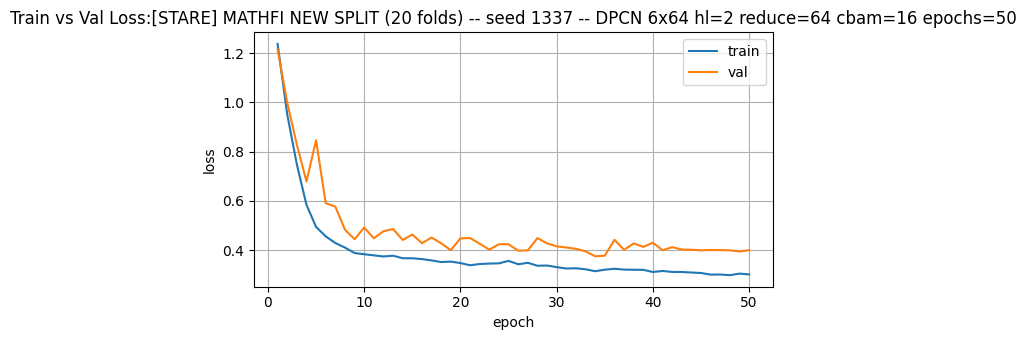

== [F06] 07_test == 
SEN=0.6681
SPE=0.9859
CLDICE=0.7180
ACC=0.9612
Dice=0.7278
IoU=0.5720
AUC=0.9769
== Predictions SAVED TO FILE: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\predictions\07_test__fold06.pt ==


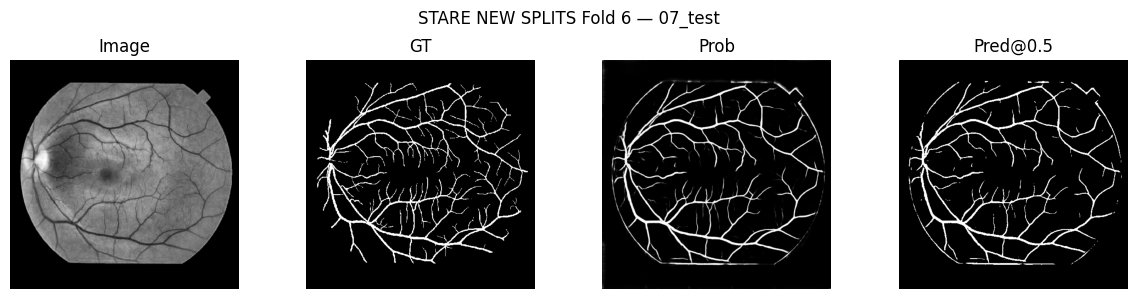


========== MATHFI STARE NEW SPLIT, Fold 8/20 ==========


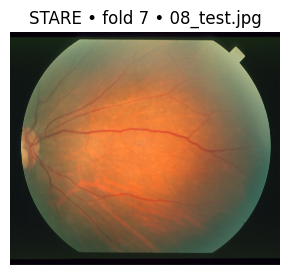

[F07 E001] train=1.2210 val=1.3001 lr=1.20e-04 time=34.1s
	CHECKPOINT SAVED: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\checkpoints\STARE_fold07.pth
[F07 E002] train=0.9406 val=1.0113 lr=1.80e-04 time=34.5s
	CHECKPOINT SAVED: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\checkpoints\STARE_fold07.pth
[F07 E003] train=0.7252 val=0.7721 lr=2.40e-04 time=34.1s
	CHECKPOINT SAVED: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\checkpoints\STARE_fold07.pth
[F07 E004] train=0.5740 val=0.6370 lr=3.00e-04 time=33.7s
	CHECKPOINT SAVED: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\checkpoints\STARE_fold07.pth
[F07 E005] train=0.4954 val=0.6580 lr=3.00e-04 time=33.9s
[F07 E006] train=0.4569 val=0.5672 lr=3.00e-04 time=35.5s
	CHECKPOINT SAVED: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\checkpoints\STARE_fold07.pth
[F07 E007] train=0.4361 val=0.5507 lr=2.99e-04 time=35.1s
	CHECKPOINT SAVED: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\checkpoints\STARE_fold07.pth
[F07 E008] train=0.4217 val=0.5345 lr=2.97e-04 time=33.9s
	CHECKPOINT SAVED: .

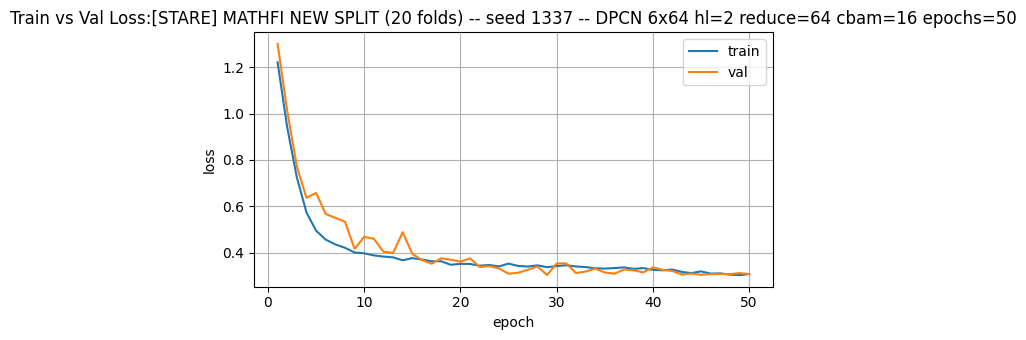

== [F07] 08_test == 
SEN=0.7365
SPE=0.9951
CLDICE=0.8179
ACC=0.9838
Dice=0.7986
IoU=0.6647
AUC=0.9897
== Predictions SAVED TO FILE: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\predictions\08_test__fold07.pt ==


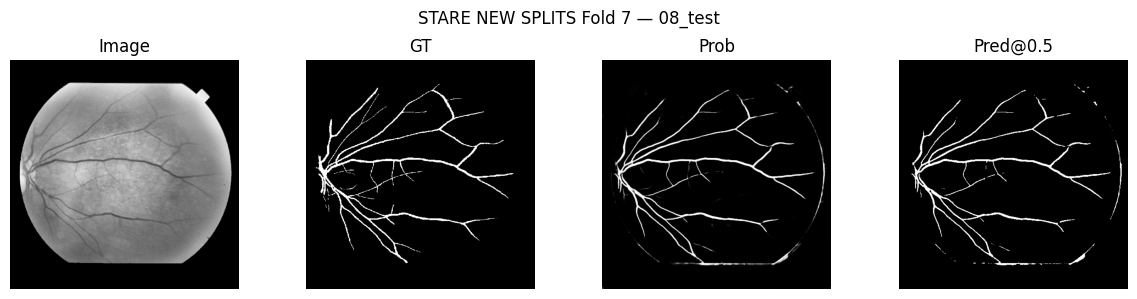


========== MATHFI STARE NEW SPLIT, Fold 9/20 ==========


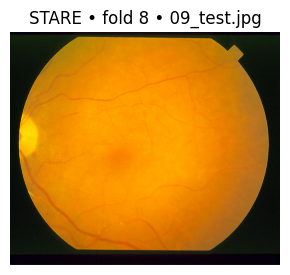

[F08 E001] train=1.0808 val=1.0137 lr=1.20e-04 time=34.6s
	CHECKPOINT SAVED: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\checkpoints\STARE_fold08.pth
[F08 E002] train=0.8211 val=0.9330 lr=1.80e-04 time=33.8s
	CHECKPOINT SAVED: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\checkpoints\STARE_fold08.pth
[F08 E003] train=0.6538 val=0.7716 lr=2.40e-04 time=34.2s
	CHECKPOINT SAVED: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\checkpoints\STARE_fold08.pth
[F08 E004] train=0.5403 val=0.7618 lr=3.00e-04 time=34.3s
	CHECKPOINT SAVED: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\checkpoints\STARE_fold08.pth
[F08 E005] train=0.4939 val=0.5207 lr=3.00e-04 time=33.1s
	CHECKPOINT SAVED: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\checkpoints\STARE_fold08.pth
[F08 E006] train=0.4378 val=0.5725 lr=3.00e-04 time=34.9s
[F08 E007] train=0.4277 val=0.5344 lr=2.99e-04 time=36.5s
[F08 E008] train=0.4239 val=0.4883 lr=2.97e-04 time=34.0s
	CHECKPOINT SAVED: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\checkpoints\STARE_fold08.pth
[F08 E009] train=0.4

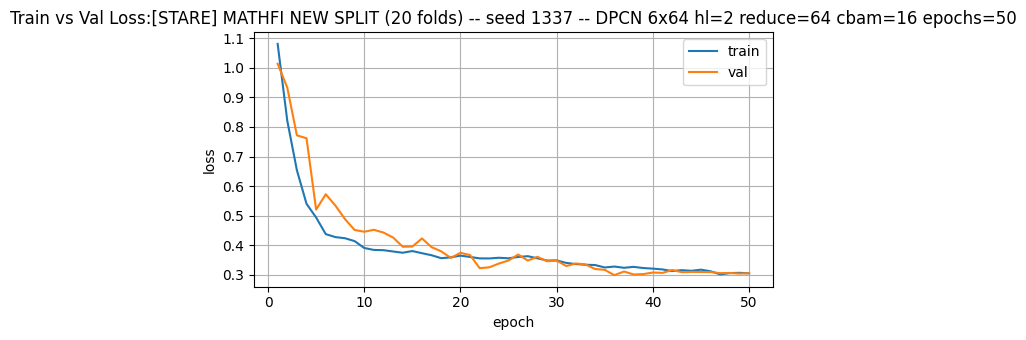

== [F08] 09_test == 
SEN=0.7062
SPE=0.9924
CLDICE=0.7964
ACC=0.9817
Dice=0.7430
IoU=0.5911
AUC=0.9887
== Predictions SAVED TO FILE: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\predictions\09_test__fold08.pt ==


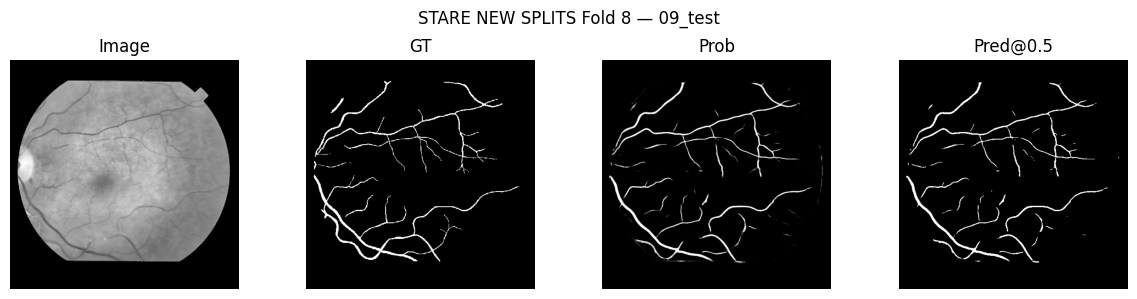


========== MATHFI STARE NEW SPLIT, Fold 10/20 ==========


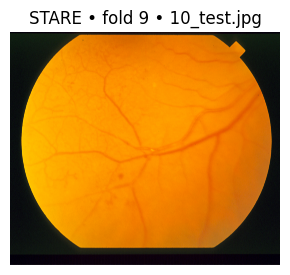

[F09 E001] train=1.0973 val=1.1717 lr=1.20e-04 time=34.2s
	CHECKPOINT SAVED: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\checkpoints\STARE_fold09.pth
[F09 E002] train=0.8208 val=0.9094 lr=1.80e-04 time=34.9s
	CHECKPOINT SAVED: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\checkpoints\STARE_fold09.pth
[F09 E003] train=0.6383 val=0.6989 lr=2.40e-04 time=33.2s
	CHECKPOINT SAVED: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\checkpoints\STARE_fold09.pth
[F09 E004] train=0.5247 val=0.6297 lr=3.00e-04 time=33.5s
	CHECKPOINT SAVED: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\checkpoints\STARE_fold09.pth
[F09 E005] train=0.4721 val=0.7551 lr=3.00e-04 time=34.4s
[F09 E006] train=0.4443 val=0.6723 lr=3.00e-04 time=34.6s
[F09 E007] train=0.4322 val=0.5056 lr=2.99e-04 time=34.2s
	CHECKPOINT SAVED: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\checkpoints\STARE_fold09.pth
[F09 E008] train=0.4222 val=0.5305 lr=2.97e-04 time=33.2s
[F09 E009] train=0.4015 val=0.4720 lr=2.94e-04 time=36.4s
	CHECKPOINT SAVED: ..\..\..\..\pth\MATHFI_STARE_

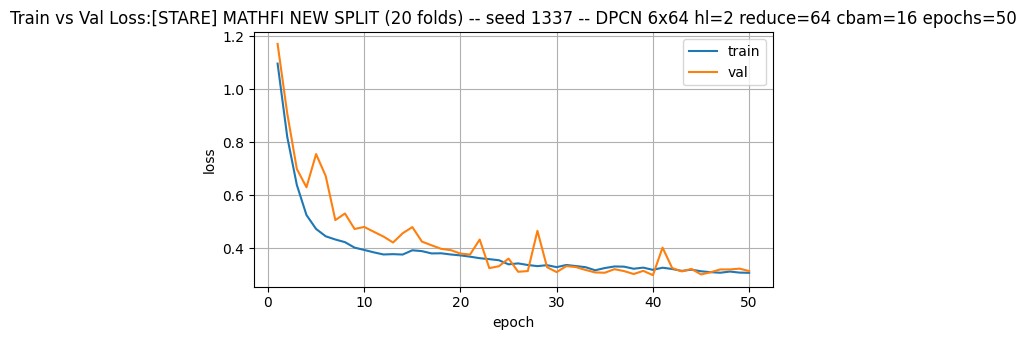

== [F09] 10_test == 
SEN=0.6760
SPE=0.9880
CLDICE=0.7676
ACC=0.9700
Dice=0.7220
IoU=0.5650
AUC=0.9764
== Predictions SAVED TO FILE: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\predictions\10_test__fold09.pt ==


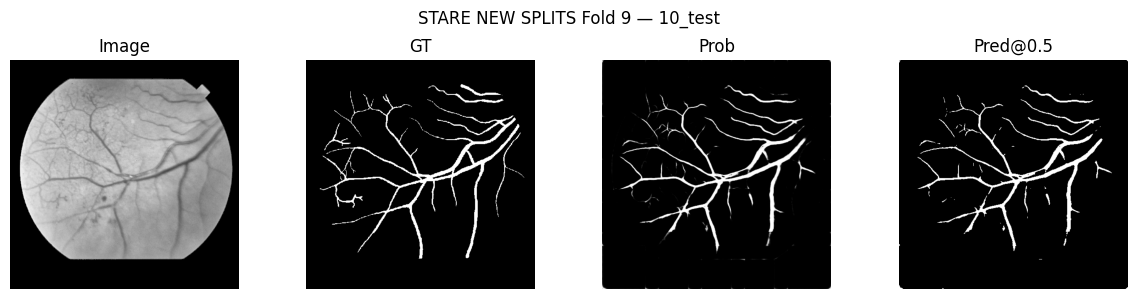


========== MATHFI STARE NEW SPLIT, Fold 11/20 ==========


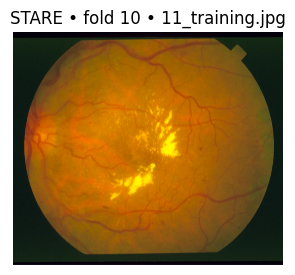

[F10 E001] train=1.1108 val=1.1099 lr=1.20e-04 time=34.6s
	CHECKPOINT SAVED: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\checkpoints\STARE_fold10.pth
[F10 E002] train=0.8469 val=0.9825 lr=1.80e-04 time=36.5s
	CHECKPOINT SAVED: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\checkpoints\STARE_fold10.pth
[F10 E003] train=0.6643 val=0.7698 lr=2.40e-04 time=34.9s
	CHECKPOINT SAVED: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\checkpoints\STARE_fold10.pth
[F10 E004] train=0.5355 val=0.5779 lr=3.00e-04 time=34.0s
	CHECKPOINT SAVED: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\checkpoints\STARE_fold10.pth
[F10 E005] train=0.4715 val=0.5187 lr=3.00e-04 time=35.5s
	CHECKPOINT SAVED: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\checkpoints\STARE_fold10.pth
[F10 E006] train=0.4438 val=0.5359 lr=3.00e-04 time=33.6s
[F10 E007] train=0.4283 val=0.5373 lr=2.99e-04 time=34.2s
[F10 E008] train=0.4147 val=0.5706 lr=2.97e-04 time=34.7s
[F10 E009] train=0.3967 val=0.5285 lr=2.94e-04 time=35.0s
[F10 E010] train=0.3950 val=0.4496 lr=2.91e-04 t

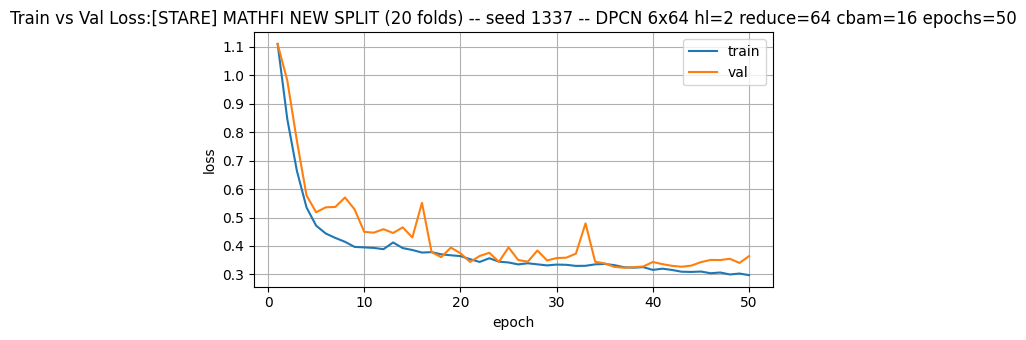

== [F10] 11_training == 
SEN=0.7501
SPE=0.9828
CLDICE=0.7919
ACC=0.9667
Dice=0.7568
IoU=0.6087
AUC=0.9807
== Predictions SAVED TO FILE: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\predictions\11_training__fold10.pt ==


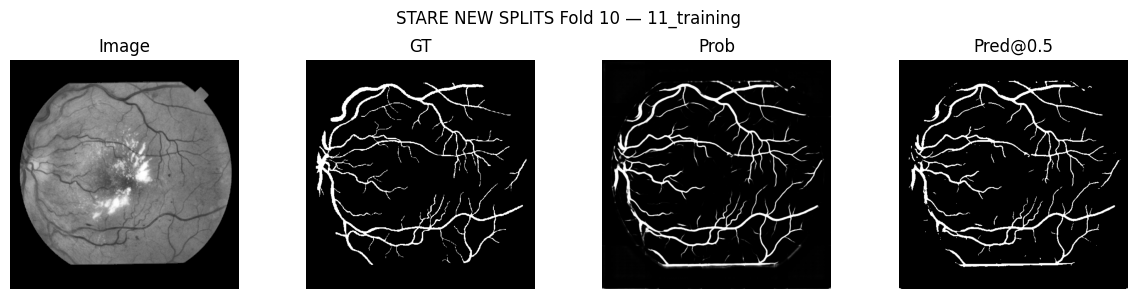


========== MATHFI STARE NEW SPLIT, Fold 12/20 ==========


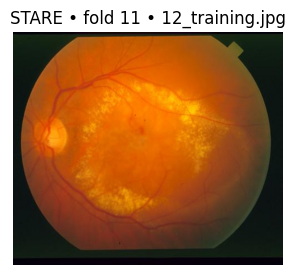

[F11 E001] train=1.2080 val=1.3010 lr=1.20e-04 time=35.7s
	CHECKPOINT SAVED: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\checkpoints\STARE_fold11.pth
[F11 E002] train=0.9184 val=1.0419 lr=1.80e-04 time=37.9s
	CHECKPOINT SAVED: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\checkpoints\STARE_fold11.pth
[F11 E003] train=0.7169 val=0.8855 lr=2.40e-04 time=37.4s
	CHECKPOINT SAVED: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\checkpoints\STARE_fold11.pth
[F11 E004] train=0.5518 val=0.6502 lr=3.00e-04 time=37.9s
	CHECKPOINT SAVED: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\checkpoints\STARE_fold11.pth
[F11 E005] train=0.4852 val=0.5579 lr=3.00e-04 time=36.5s
	CHECKPOINT SAVED: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\checkpoints\STARE_fold11.pth
[F11 E006] train=0.4357 val=0.5402 lr=3.00e-04 time=36.0s
	CHECKPOINT SAVED: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\checkpoints\STARE_fold11.pth
[F11 E007] train=0.4306 val=0.5523 lr=2.99e-04 time=35.8s
[F11 E008] train=0.4095 val=0.5081 lr=2.97e-04 time=36.8s
	CHECKPOINT SAVED: .

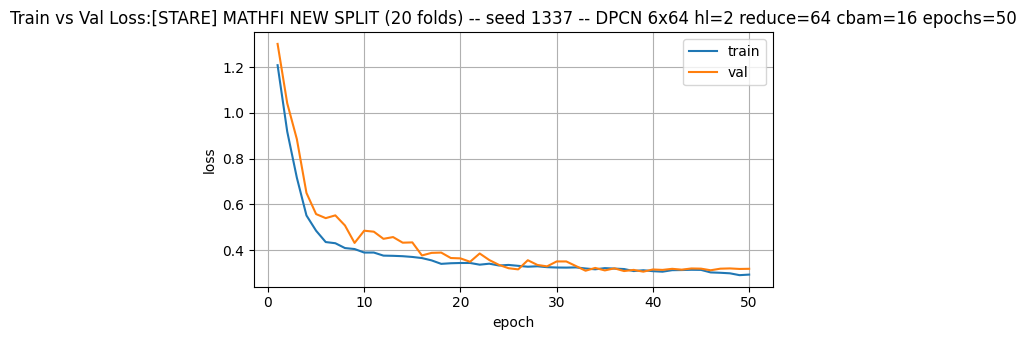

== [F11] 12_training == 
SEN=0.6036
SPE=0.9918
CLDICE=0.7025
ACC=0.9694
Dice=0.6949
IoU=0.5324
AUC=0.9623
== Predictions SAVED TO FILE: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\predictions\12_training__fold11.pt ==


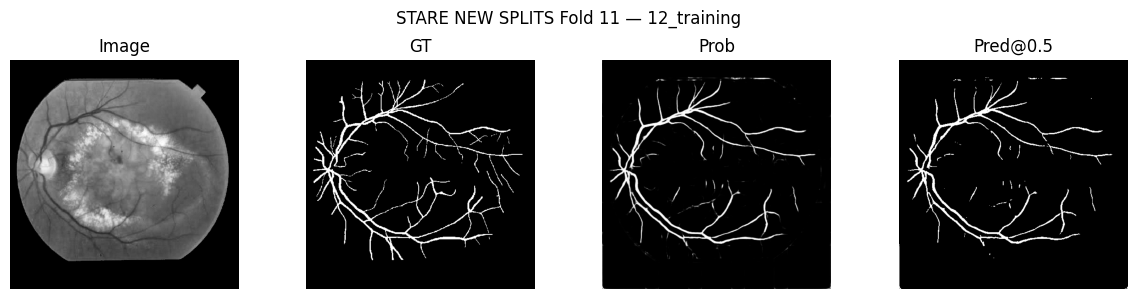


========== MATHFI STARE NEW SPLIT, Fold 13/20 ==========


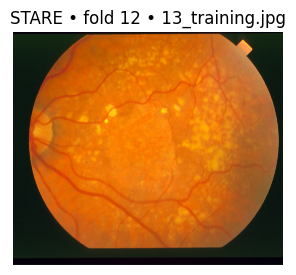

[F12 E001] train=1.0033 val=1.0959 lr=1.20e-04 time=34.6s
	CHECKPOINT SAVED: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\checkpoints\STARE_fold12.pth
[F12 E002] train=0.7391 val=0.8544 lr=1.80e-04 time=36.8s
	CHECKPOINT SAVED: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\checkpoints\STARE_fold12.pth
[F12 E003] train=0.5946 val=0.7211 lr=2.40e-04 time=33.5s
	CHECKPOINT SAVED: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\checkpoints\STARE_fold12.pth
[F12 E004] train=0.5056 val=0.6308 lr=3.00e-04 time=34.9s
	CHECKPOINT SAVED: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\checkpoints\STARE_fold12.pth
[F12 E005] train=0.4625 val=0.6138 lr=3.00e-04 time=34.0s
	CHECKPOINT SAVED: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\checkpoints\STARE_fold12.pth
[F12 E006] train=0.4439 val=0.5761 lr=3.00e-04 time=33.1s
	CHECKPOINT SAVED: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\checkpoints\STARE_fold12.pth
[F12 E007] train=0.4320 val=0.5224 lr=2.99e-04 time=34.8s
	CHECKPOINT SAVED: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\checkpoints\STARE_fol

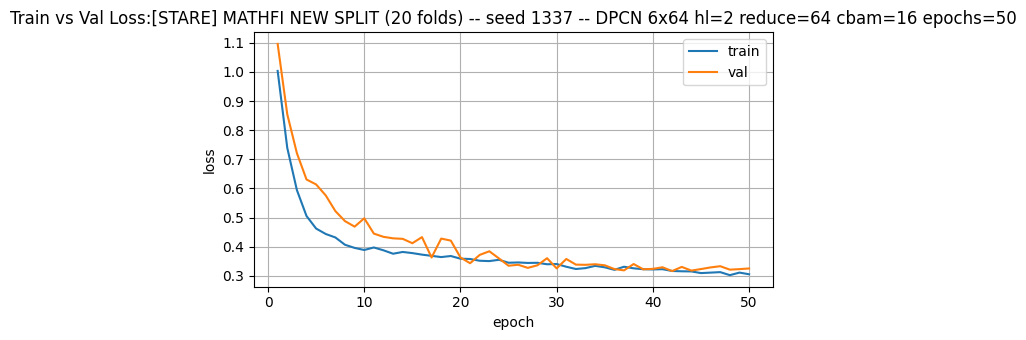

== [F12] 13_training == 
SEN=0.7906
SPE=0.9886
CLDICE=0.7944
ACC=0.9783
Dice=0.7903
IoU=0.6533
AUC=0.9896
== Predictions SAVED TO FILE: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\predictions\13_training__fold12.pt ==


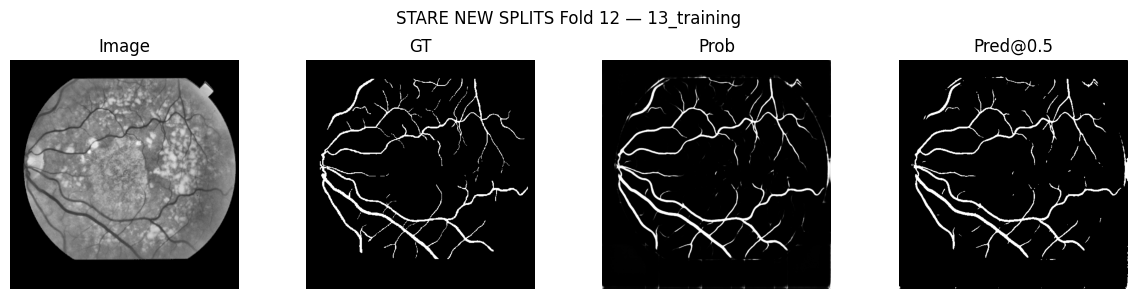


========== MATHFI STARE NEW SPLIT, Fold 14/20 ==========


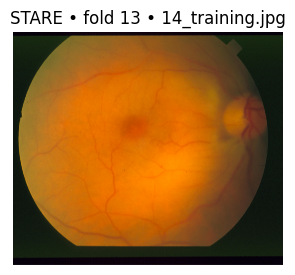

[F13 E001] train=1.1275 val=1.2646 lr=1.20e-04 time=33.8s
	CHECKPOINT SAVED: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\checkpoints\STARE_fold13.pth
[F13 E002] train=0.8570 val=0.9051 lr=1.80e-04 time=37.8s
	CHECKPOINT SAVED: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\checkpoints\STARE_fold13.pth
[F13 E003] train=0.6544 val=0.7334 lr=2.40e-04 time=34.5s
	CHECKPOINT SAVED: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\checkpoints\STARE_fold13.pth
[F13 E004] train=0.5385 val=0.6409 lr=3.00e-04 time=34.9s
	CHECKPOINT SAVED: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\checkpoints\STARE_fold13.pth
[F13 E005] train=0.4767 val=0.6545 lr=3.00e-04 time=34.5s
[F13 E006] train=0.4527 val=0.6359 lr=3.00e-04 time=34.5s
	CHECKPOINT SAVED: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\checkpoints\STARE_fold13.pth
[F13 E007] train=0.4395 val=0.5870 lr=2.99e-04 time=32.7s
	CHECKPOINT SAVED: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\checkpoints\STARE_fold13.pth
[F13 E008] train=0.4193 val=0.6174 lr=2.97e-04 time=34.4s
[F13 E009] train=0.4

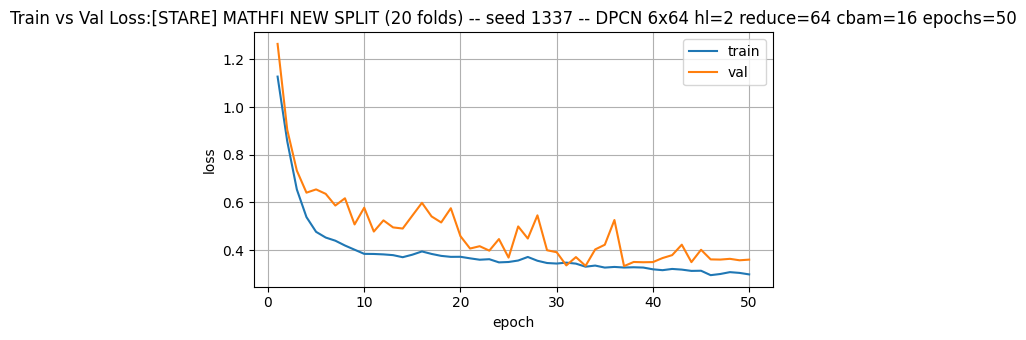

== [F13] 14_training == 
SEN=0.5889
SPE=0.9931
CLDICE=0.7923
ACC=0.9672
Dice=0.6969
IoU=0.5348
AUC=0.9807
== Predictions SAVED TO FILE: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\predictions\14_training__fold13.pt ==


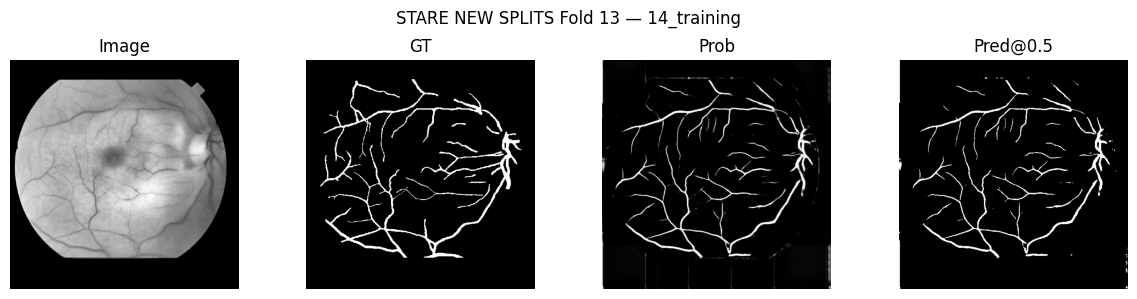


========== MATHFI STARE NEW SPLIT, Fold 15/20 ==========


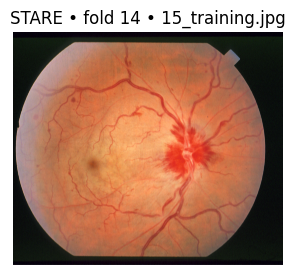

[F14 E001] train=1.0972 val=1.2493 lr=1.20e-04 time=32.7s
	CHECKPOINT SAVED: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\checkpoints\STARE_fold14.pth
[F14 E002] train=0.8185 val=0.9137 lr=1.80e-04 time=34.4s
	CHECKPOINT SAVED: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\checkpoints\STARE_fold14.pth
[F14 E003] train=0.6287 val=0.7340 lr=2.40e-04 time=35.0s
	CHECKPOINT SAVED: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\checkpoints\STARE_fold14.pth
[F14 E004] train=0.5135 val=0.5875 lr=3.00e-04 time=34.5s
	CHECKPOINT SAVED: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\checkpoints\STARE_fold14.pth
[F14 E005] train=0.4644 val=0.6531 lr=3.00e-04 time=35.2s
[F14 E006] train=0.4382 val=0.6710 lr=3.00e-04 time=36.9s
[F14 E007] train=0.4266 val=0.6468 lr=2.99e-04 time=33.9s
[F14 E008] train=0.4053 val=0.5244 lr=2.97e-04 time=33.9s
	CHECKPOINT SAVED: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\checkpoints\STARE_fold14.pth
[F14 E009] train=0.4072 val=0.4982 lr=2.94e-04 time=33.9s
	CHECKPOINT SAVED: ..\..\..\..\pth\MATHFI_STARE_

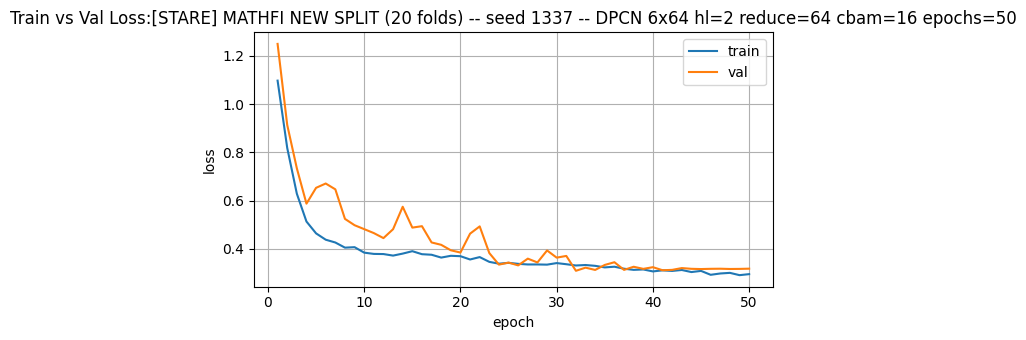

== [F14] 15_training == 
SEN=0.6126
SPE=0.9921
CLDICE=0.7998
ACC=0.9623
Dice=0.7182
IoU=0.5603
AUC=0.9852
== Predictions SAVED TO FILE: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\predictions\15_training__fold14.pt ==


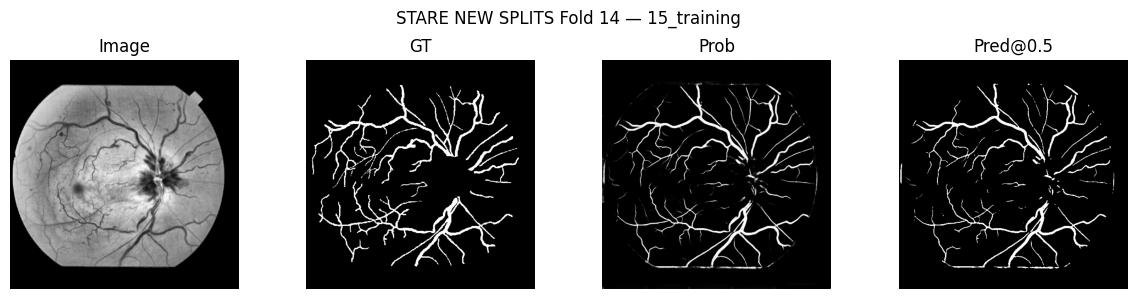


========== MATHFI STARE NEW SPLIT, Fold 16/20 ==========


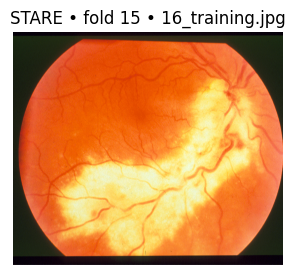

[F15 E001] train=1.0274 val=1.2353 lr=1.20e-04 time=34.2s
	CHECKPOINT SAVED: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\checkpoints\STARE_fold15.pth
[F15 E002] train=0.7684 val=0.9363 lr=1.80e-04 time=34.7s
	CHECKPOINT SAVED: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\checkpoints\STARE_fold15.pth
[F15 E003] train=0.6190 val=0.7640 lr=2.40e-04 time=33.8s
	CHECKPOINT SAVED: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\checkpoints\STARE_fold15.pth
[F15 E004] train=0.5072 val=0.6325 lr=3.00e-04 time=34.8s
	CHECKPOINT SAVED: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\checkpoints\STARE_fold15.pth
[F15 E005] train=0.4740 val=0.6625 lr=3.00e-04 time=34.4s
[F15 E006] train=0.4405 val=0.5563 lr=3.00e-04 time=35.0s
	CHECKPOINT SAVED: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\checkpoints\STARE_fold15.pth
[F15 E007] train=0.4240 val=0.6447 lr=2.99e-04 time=36.6s
[F15 E008] train=0.4259 val=0.5729 lr=2.97e-04 time=34.0s
[F15 E009] train=0.4014 val=0.5241 lr=2.94e-04 time=35.1s
	CHECKPOINT SAVED: ..\..\..\..\pth\MATHFI_STARE_

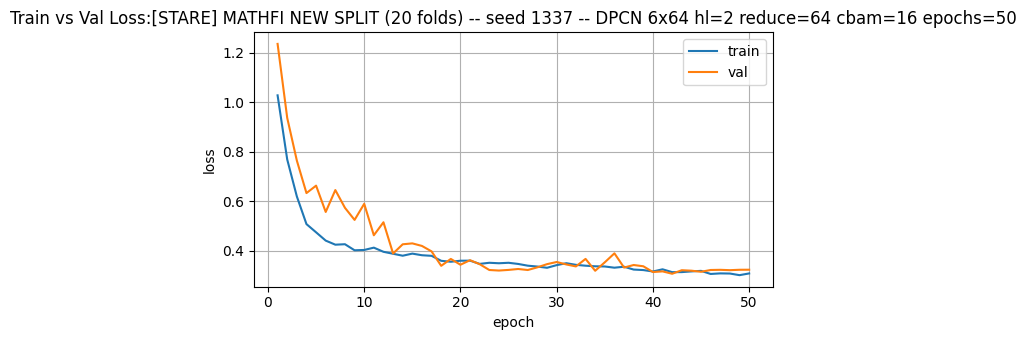

== [F15] 16_training == 
SEN=0.8284
SPE=0.9817
CLDICE=0.8110
ACC=0.9724
Dice=0.7837
IoU=0.6443
AUC=0.9899
== Predictions SAVED TO FILE: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\predictions\16_training__fold15.pt ==


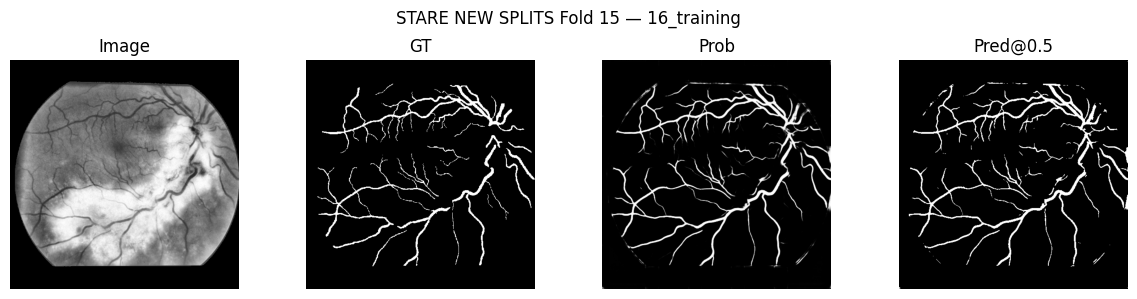


========== MATHFI STARE NEW SPLIT, Fold 17/20 ==========


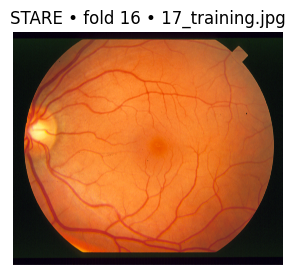

[F16 E001] train=1.1745 val=1.3252 lr=1.20e-04 time=34.2s
	CHECKPOINT SAVED: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\checkpoints\STARE_fold16.pth
[F16 E002] train=0.8579 val=0.9216 lr=1.80e-04 time=34.3s
	CHECKPOINT SAVED: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\checkpoints\STARE_fold16.pth
[F16 E003] train=0.6817 val=0.7691 lr=2.40e-04 time=33.3s
	CHECKPOINT SAVED: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\checkpoints\STARE_fold16.pth
[F16 E004] train=0.5510 val=0.7154 lr=3.00e-04 time=34.2s
	CHECKPOINT SAVED: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\checkpoints\STARE_fold16.pth
[F16 E005] train=0.4907 val=0.6317 lr=3.00e-04 time=33.2s
	CHECKPOINT SAVED: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\checkpoints\STARE_fold16.pth
[F16 E006] train=0.4555 val=0.6092 lr=3.00e-04 time=33.6s
	CHECKPOINT SAVED: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\checkpoints\STARE_fold16.pth
[F16 E007] train=0.4389 val=0.5603 lr=2.99e-04 time=35.4s
	CHECKPOINT SAVED: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\checkpoints\STARE_fol

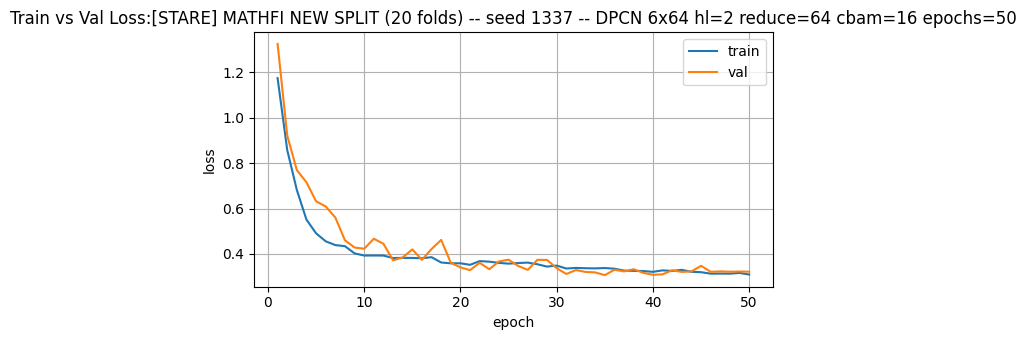

== [F16] 17_training == 
SEN=0.8974
SPE=0.9786
CLDICE=0.8512
ACC=0.9730
Dice=0.8216
IoU=0.6972
AUC=0.9929
== Predictions SAVED TO FILE: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\predictions\17_training__fold16.pt ==


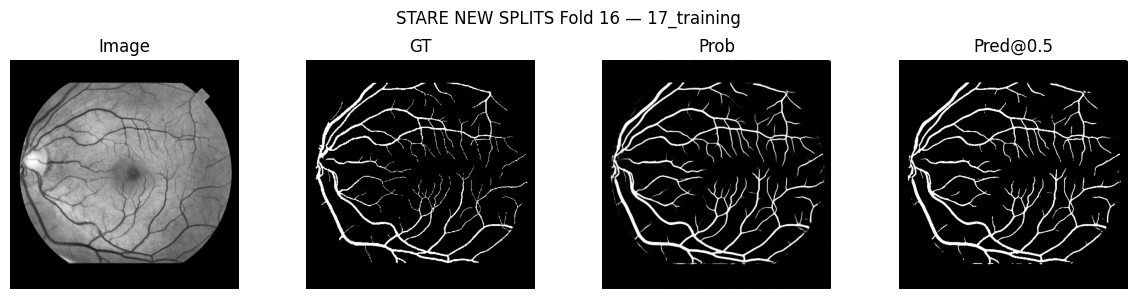


========== MATHFI STARE NEW SPLIT, Fold 18/20 ==========


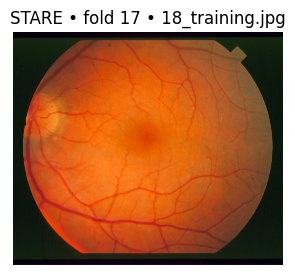

[F17 E001] train=1.1506 val=1.3459 lr=1.20e-04 time=33.5s
	CHECKPOINT SAVED: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\checkpoints\STARE_fold17.pth
[F17 E002] train=0.8809 val=1.0080 lr=1.80e-04 time=35.6s
	CHECKPOINT SAVED: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\checkpoints\STARE_fold17.pth
[F17 E003] train=0.6936 val=0.8113 lr=2.40e-04 time=34.1s
	CHECKPOINT SAVED: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\checkpoints\STARE_fold17.pth
[F17 E004] train=0.5662 val=0.6620 lr=3.00e-04 time=33.5s
	CHECKPOINT SAVED: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\checkpoints\STARE_fold17.pth
[F17 E005] train=0.4900 val=0.6663 lr=3.00e-04 time=34.9s
[F17 E006] train=0.4528 val=0.6574 lr=3.00e-04 time=33.5s
	CHECKPOINT SAVED: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\checkpoints\STARE_fold17.pth
[F17 E007] train=0.4339 val=0.6013 lr=2.99e-04 time=34.5s
	CHECKPOINT SAVED: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\checkpoints\STARE_fold17.pth
[F17 E008] train=0.4230 val=0.4948 lr=2.97e-04 time=32.2s
	CHECKPOINT SAVED: .

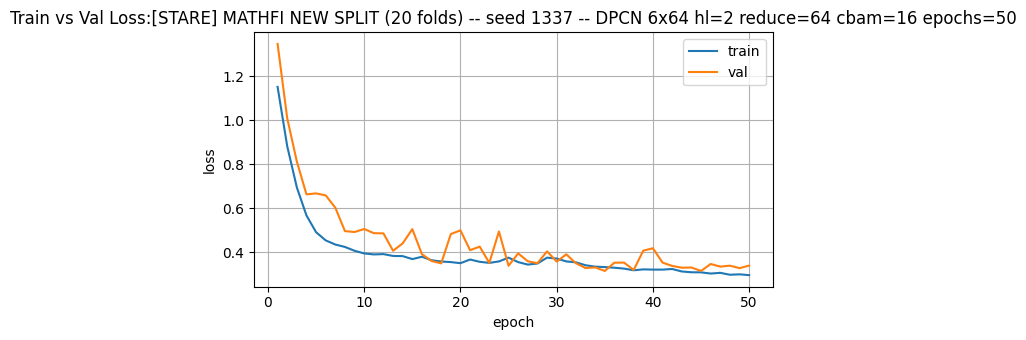

== [F17] 18_training == 
SEN=0.8234
SPE=0.9823
CLDICE=0.8315
ACC=0.9720
Dice=0.7925
IoU=0.6564
AUC=0.9889
== Predictions SAVED TO FILE: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\predictions\18_training__fold17.pt ==


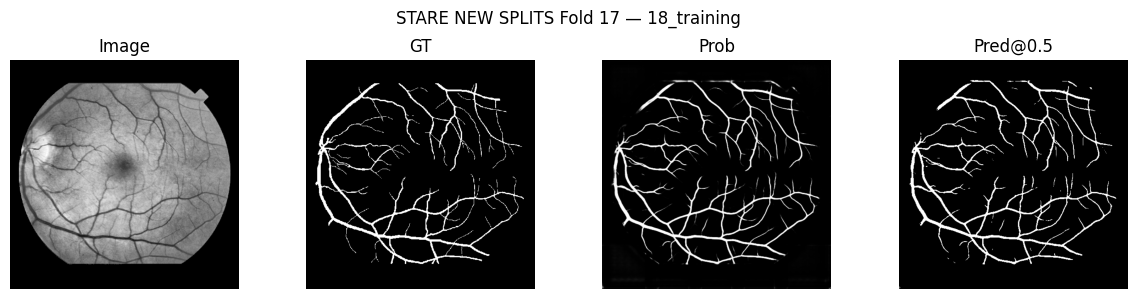


========== MATHFI STARE NEW SPLIT, Fold 19/20 ==========


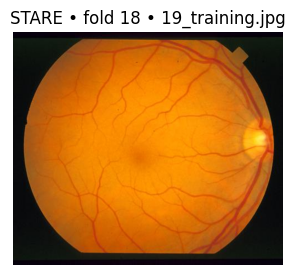

[F18 E001] train=1.1924 val=1.4799 lr=1.20e-04 time=36.7s
	CHECKPOINT SAVED: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\checkpoints\STARE_fold18.pth
[F18 E002] train=0.9285 val=0.9998 lr=1.80e-04 time=34.4s
	CHECKPOINT SAVED: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\checkpoints\STARE_fold18.pth
[F18 E003] train=0.7310 val=0.8262 lr=2.40e-04 time=35.1s
	CHECKPOINT SAVED: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\checkpoints\STARE_fold18.pth
[F18 E004] train=0.5837 val=0.6880 lr=3.00e-04 time=34.2s
	CHECKPOINT SAVED: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\checkpoints\STARE_fold18.pth
[F18 E005] train=0.5054 val=0.6387 lr=3.00e-04 time=35.5s
	CHECKPOINT SAVED: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\checkpoints\STARE_fold18.pth
[F18 E006] train=0.4567 val=0.6722 lr=3.00e-04 time=34.3s
[F18 E007] train=0.4354 val=0.5664 lr=2.99e-04 time=33.4s
	CHECKPOINT SAVED: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\checkpoints\STARE_fold18.pth
[F18 E008] train=0.4337 val=0.4848 lr=2.97e-04 time=33.3s
	CHECKPOINT SAVED: .

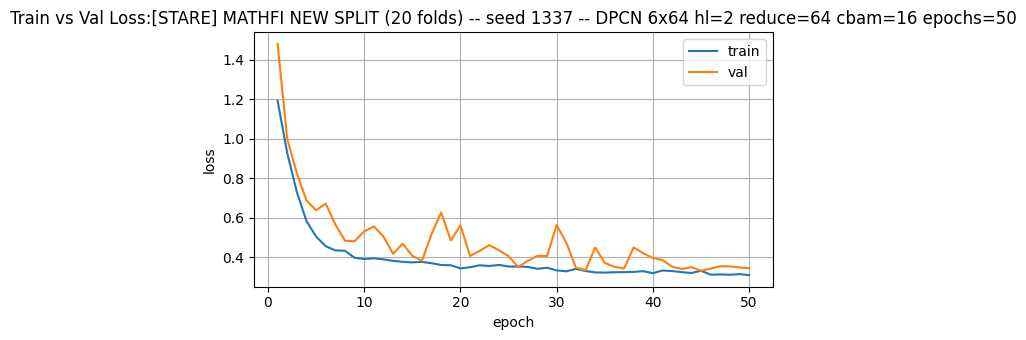

== [F18] 19_training == 
SEN=0.8124
SPE=0.9777
CLDICE=0.7985
ACC=0.9664
Dice=0.7677
IoU=0.6229
AUC=0.9833
== Predictions SAVED TO FILE: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\predictions\19_training__fold18.pt ==


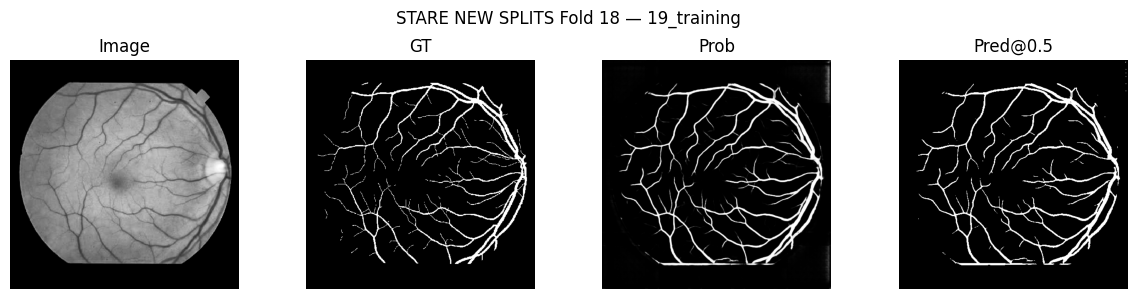


========== MATHFI STARE NEW SPLIT, Fold 20/20 ==========


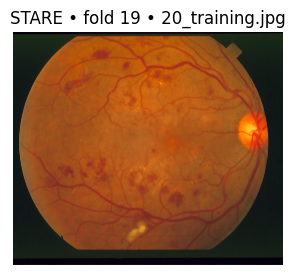

[F19 E001] train=1.0705 val=1.3962 lr=1.20e-04 time=34.8s
	CHECKPOINT SAVED: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\checkpoints\STARE_fold19.pth
[F19 E002] train=0.7992 val=0.8738 lr=1.80e-04 time=35.1s
	CHECKPOINT SAVED: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\checkpoints\STARE_fold19.pth
[F19 E003] train=0.6316 val=0.7457 lr=2.40e-04 time=35.5s
	CHECKPOINT SAVED: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\checkpoints\STARE_fold19.pth
[F19 E004] train=0.5269 val=0.7251 lr=3.00e-04 time=37.2s
	CHECKPOINT SAVED: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\checkpoints\STARE_fold19.pth
[F19 E005] train=0.4831 val=0.6584 lr=3.00e-04 time=34.0s
	CHECKPOINT SAVED: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\checkpoints\STARE_fold19.pth
[F19 E006] train=0.4535 val=0.5678 lr=3.00e-04 time=34.9s
	CHECKPOINT SAVED: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\checkpoints\STARE_fold19.pth
[F19 E007] train=0.4349 val=0.6028 lr=2.99e-04 time=34.8s
[F19 E008] train=0.4208 val=0.5404 lr=2.97e-04 time=35.5s
	CHECKPOINT SAVED: .

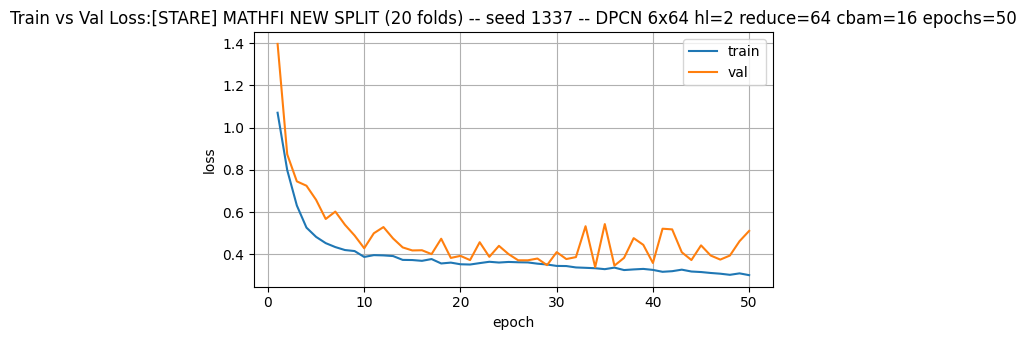

== [F19] 20_training == 
SEN=0.7986
SPE=0.9844
CLDICE=0.8161
ACC=0.9715
Dice=0.7956
IoU=0.6606
AUC=0.9877
== Predictions SAVED TO FILE: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\predictions\20_training__fold19.pt ==


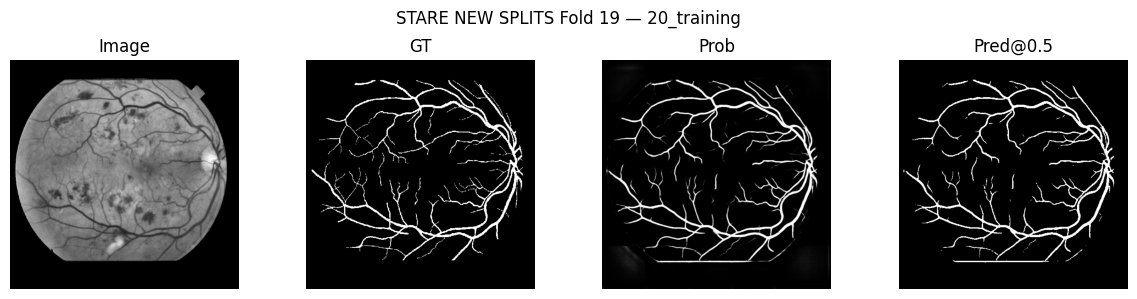


=== MATHFI STARE NEW SPLITS (20 folds) — mean ± std ===
SEN: 0.7463 ± 0.0904
SPE: 0.9862 ± 0.0056
CLDICE: 0.7961 ± 0.0396
ACC: 0.9704 ± 0.0059
Dice: 0.7657 ± 0.0386
IoU: 0.6218 ± 0.0502
AUC: 0.9843 ± 0.0074
AP: 0.8609 ± 0.0358


In [12]:
all_metrics, summary = run_stare_loo_experiment(
    root=DATASET_ROOT,
    label_folder=DATASET_LABELFOLDER,
    epochs=EPOCHS,
    warmup=warmup_epochs,
    batch_size=BATCH_SIZE,
    img_size=IMG_SIZE,
    patch_train=True,
    patch_size=PATCH_SIZE,
    vessel_bias_p=VESSEL_BIAS,
    threshold_eval=THRESHOLD_EVAL,
    folds=FOLDS,
    fold_id=FOLD_ID,   #starts at any fold_id

    chckpnt_paths= [
         #"..\..\..\..\pth\{MODEL_NAME}_STARE_NEWSPLIT\checkpoints\STARE_fold00.pth",
         #"..\..\..\..\pth\{MODEL_NAME}_STARE_NEWSPLIT\checkpoints\STARE_fold01.pth",
         #"..\..\..\..\pth\{MODEL_NAME}_STARE_NEWSPLIT\checkpoints\STARE_fold02.pth"

    ]
)
